# Simulations light inter

In [1]:
from __future__ import annotations

import math
import os
import sys
import time as t
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns

sys.path.append(".") 
from plot_outputs import *

sys.path.append("../data") 
from archi_dict import archi_sorghum as archi_1
from archi_dict import archi_maize as archi_2

# from openalea.archicrop.display import build_scene, display_scene  # noqa: F401
from openalea.archicrop.simulation import compute_extinction_coef, concat_usm
# from openalea.plantgl.all import Color3, Material, Scene  # noqa: F401


# %gui qt

In [2]:
def open_ds(n_cpu, folder="../simulations_ArchiCrop/"):
    file_list = []
    for cpu in range(n_cpu):
        file_list.append(folder + f"results_light_inter_{cpu}.nc")
    ds = concat_usm(file_list)
    return ds

def open_ds_usms(usms, folder = "../simulations_ArchiCrop/"):
    file_list = []
    for usm in usms:
        file_list.append(folder + f"results_light_inter_usm_{usm}.nc") 
    ds = concat_usm(file_list)
    return ds


In [3]:
usms = [1,2,3,4,5,6,10,12,14,16,18,22,24,26]
id_usm = [f"usm_{i}" for i in usms]
usms_dict = dict(zip(range(len(usms)),usms))
n_cpu = len(usms)
ds = open_ds_usms(usms_dict.values(), folder = "../simulations_ArchiCrop/")
ds

<xarray.Dataset> Size: 2MB
Dimensions:                 (usm: 14, algo: 2, plant: 2, date: 365, id: 1)
Coordinates:
  * usm                     (usm) object 112B 'usm_1' 'usm_2' ... 'usm_26'
  * algo                    (algo) object 16B '2.5D' 'Beer'
  * plant                   (plant) object 16B 'maize' 'sorghum'
  * date                    (date) object 3kB '2018-01-01' ... '2018-12-31'
  * id                      (id) int32 4B 0
Data variables: (12/42)
    thermal_time            (usm, algo, plant, date) float64 164kB nan ... nan
    lai_stics               (usm, algo, plant, date) float64 164kB nan ... nan
    sen_lai_stics           (usm, algo, plant, date) float64 164kB nan ... nan
    height_stics            (usm, algo, plant, date) float64 164kB nan ... nan
    inc_par                 (usm, algo, plant, date) float64 164kB nan ... nan
    abs_par_stics           (usm, algo, plant, date) float64 164kB nan ... nan
    ...                      ...
    reduction_factor        (usm, algo, plant, id) float64 448B 1.0 0.5 ... 0.5
    tropism_coefficient     (usm, algo, plant, id) float64 448B 0.05 ... 0.12
    leaf_lifespan           (usm, algo, plant, id) float64 448B 200.0 ... 280.0
    leaf_lifespan_early     (usm, algo, plant, id) float64 448B 160.0 ... 224.0
    nb_phy                  (usm, algo, plant, id) int32 224B 20 16 20 ... 20 16
    domain_area             (usm, algo) float64 224B 0.96 0.96 ... 0.72 0.72

In [4]:
usms_str = ds.usm.values
algos = ds.algo.values
plants = ds.plant.values
dates = ds.date.values
# dates = pd.to_datetime(dates)
# dates = dates.strftime('%Y-%m-%d')
density = {usm: {algo: {plant: np.nanmin(np.array(ds.density.values[u][a][p])) for p,plant in enumerate(plants) if ds.density.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}


In [5]:
from openalea.archicrop.stics_io import read_doe_intercrop

plant_1 = "sorghum"
plant_2 = "maize"

row_orientation_values = {
"N-S" : 0,
"E-W" : math.pi / 2
}

interrow_distance_per_species = {
"sorghum" : {
    "high" : 0.8,
    "middle" : 0.4,
    "low" : 0.2
},
"maize_trop" : {
    "high" : 0.8,
    "middle" : 0.4,
    "low" : 0.2
}
}

n_rows_per_species = {
"sorghum" : {
    "one" : 1, # For non-strip, this is just one row
    "high" : 6,
    "middle" : 4,
    "low" : 2
},
"maize_trop" : {
    "one" : 1,
    "high" : 6,
    "middle" : 4,
    "low" : 2
}
}

intrarow_distance_per_species = {
"sorghum" : {
    "high" : 0.8,
    "middle" : 0.4, # ~6 plants per m2 with 0.4m interrow distance, gives 0.41m intrarow distance
    "low" : 0.2
},
"maize_trop" : {
    "high" : 0.8,
    "middle" : 0.4,
    "low" : 0.2
}
}

doe_file = "../data/usms_STICS/v11_IC_light/doe.csv"
doe = read_doe_intercrop(doe_file)

doe_adapt = {}

for usm,spat_conf in doe.items():
    if usm in id_usm:
        spat_conf["row_orientation"] = row_orientation_values[spat_conf["row_orientation"]]
        spat_conf["interrow_distance_principal"] = interrow_distance_per_species[spat_conf["species_principal"]][spat_conf["interrow_distance_principal"]]
        spat_conf["interrow_distance_secondary"] = interrow_distance_per_species[spat_conf["species_secondary"]][spat_conf["interrow_distance_secondary"]]
        spat_conf["n_rows_principal"] = 0 if spat_conf["design"] == "intercrop mixed" else n_rows_per_species[spat_conf["species_principal"]][spat_conf["n_rows_principal"]]
        spat_conf["n_rows_secondary"] = 0 if spat_conf["design"] == "intercrop mixed" else n_rows_per_species[spat_conf["species_secondary"]][spat_conf["n_rows_secondary"]]
        spat_conf["intrarow_distance"] = intrarow_distance_per_species[spat_conf["species_principal"]][spat_conf["intrarow_distance"]]

        doe_adapt[usm] = {}

        for algo in density[usm]:

            doe_adapt[usm][algo] = {}

            for p, plant in enumerate([plant_1,plant_2]):

                density_1 = density[usm][algo][plant_1]
                density_2 = density[usm][algo][plant_2]
                inter_row_1 = spat_conf["interrow_distance_principal"]
                inter_row_2 = spat_conf["interrow_distance_secondary"]
                intra_row_1 = 1/density_1/inter_row_1
                intra_row_2 = 1/density_2/inter_row_2
    
                doe_adapt[usm][algo][plant] = {
                    "design" : spat_conf["design"],
                    "density_1" : density_1,
                    "density_2" : density_2,
                    "inter_row_1" : inter_row_1,
                    "inter_row_2" : inter_row_2,
                    "width" : 2 * inter_row_1 if spat_conf["design"] == "intercrop mixed" else (spat_conf["n_rows_principal"]-1) * inter_row_1 + (spat_conf["n_rows_secondary"]-1) * inter_row_2 + 2*max(inter_row_1, inter_row_2),
                    "length" : 2 * max(intra_row_1, intra_row_2) if spat_conf["design"] == "intercrop mixed" else max(intra_row_1, intra_row_2),
                    "nb_rows" : spat_conf["n_rows_principal"] if p == 0 else spat_conf["n_rows_secondary"],
                    # "nb_rows_2" : spat_conf["n_rows_secondary"]
                }

                doe_adapt[usm][algo][plant]["nb_plant"] = 2 if spat_conf["design"] == "intercrop mixed" else doe_adapt[usm][algo][plant]["nb_rows"]

In [6]:
thermal_time = {usm: {algo: {plant: ds.thermal_time.values[u][a][p] for p,plant in enumerate(plants) if ds.thermal_time.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
leaf_area_plant = {usm: {algo: {plant: ds.lai_stics.values[u][a][p] for p,plant in enumerate(plants) if ds.lai_stics.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
sen_leaf_area_plant = {usm: {algo: {plant: ds.sen_lai_stics.values[u][a][p] for p,plant in enumerate(plants) if ds.sen_lai_stics.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
height_canopy = {usm: {algo: {plant: ds.height_stics.values[u][a][p] for p,plant in enumerate(plants) if ds.height_stics.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
par_incident = {usm: {algo: {plant: ds.inc_par.values[u][a][p] for p,plant in enumerate(plants) if ds.inc_par.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
par_stics = {usm: {algo: {plant: ds.abs_par_stics.values[u][a][p] for p,plant in enumerate(plants) if ds.abs_par_stics.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
domain_area = {usm: {algo: ds.domain_area.values[u][a] for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}

realized_la = {usm: {algo: {plant: ds.realized_la.values[u][a][p][0] for p,plant in enumerate(plants) if ds.realized_la.values[u][a][p][0] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
realized_h = {usm: {algo: {plant: ds.realized_h.values[u][a][p][0] for p,plant in enumerate(plants) if ds.realized_h.values[u][a][p][0] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}

# nrj_crop = {usm: {algo: {plant: [nrj/par_incident[usm][algo][plant][t]/domain_area[usm][algo] for t,nrj in enumerate(ds.nrj_per_leaf.values[u][a][p][0])] for p,plant in enumerate(plants) if ds.nrj_per_leaf.values[u][a][p][0] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}

nrj_crop = {usm: {algo: {plant: [nrj*doe_adapt[usm][algo][plant]["nb_plant"]/par_incident[usm][algo][plant][t]/domain_area[usm][algo] 
                                 for t,nrj in enumerate(ds.nrj_per_leaf.values[u][a][p][0])] 
                         for p,plant in enumerate(plants) if ds.nrj_per_leaf.values[u][a][p][0] is not None} 
                  for a,algo in enumerate(algos)} 
            for u,usm in enumerate(usms_str)}


In [7]:
rows = []

for u, d1 in doe_adapt.items():
    for a, d2 in d1.items():
        for p, val in d2.items():
            rows.append((u, a, p, val["nb_plant"], val["design"]))

df = pd.DataFrame(rows, columns=["usm", "algo", "plant", "nb_plant", "design"])

dan = df.set_index(["usm", "algo", "plant"]).to_xarray()["nb_plant"]
dad = df.set_index(["usm", "algo", "plant"]).to_xarray()["design"]

ds["nb_plant"] = dan
ds["design"] = dad

In [8]:
ds["nrj_crop"] = ds["nrj_per_leaf"]*ds["nb_plant"] / (ds["inc_par"] * ds["domain_area"])

In [9]:
# rows = []

# for u, d1 in ds.nrj_crop.items():
#     for a, d2 in d1.items():
#         for p, val in d2.items():
#             rows.append((u, a, p, val["nb_plant"], val["design"]))

# df = pd.DataFrame(rows, columns=["usm", "algo", "plant", "nb_plant", "design"])

# dan = df.set_index(["usm", "algo", "plant"]).to_xarray()["nb_plant"]

In [10]:
ds["green_lai"] = ds["lai_stics"] - ds["sen_lai_stics"]

In [11]:
# ds["DOY"] = pd.to_datetime(ds["date"]).dayofyear

In [12]:
# nrj_crop

In [13]:
df = ds.to_dataframe().reset_index()
df = df.dropna(subset=["abs_par_stics", "nrj_crop"])

In [14]:
long = df.melt(
    id_vars=["usm", "algo", "plant", "id", "date"],
    value_vars=["abs_par_stics", "nrj_crop"], #, "DOY"],
    # var_name="variable",
    # value_name="value",
)

In [15]:
long

,usm,algo,plant,id,date,variable,value
0,usm_2,2.5D,maize,0,2018-07-04,abs_par_stics,0.000000
1,usm_3,2.5D,maize,0,2018-07-04,abs_par_stics,0.000000
2,usm_5,2.5D,maize,0,2018-07-04,abs_par_stics,0.000000
3,usm_6,2.5D,maize,0,2018-07-04,abs_par_stics,0.000000
4,usm_10,2.5D,maize,0,2018-07-04,abs_par_stics,0.000000
...,...,...,...,...,...,...,...
11021,usm_16,Beer,sorghum,0,2018-10-14,nrj_crop,0.241805
11022,usm_18,Beer,sorghum,0,2018-10-14,nrj_crop,0.293032
11023,usm_22,Beer,sorghum,0,2018-10-14,nrj_crop,0.169195
11024,usm_24,Beer,sorghum,0,2018-10-14,nrj_crop,0.217862


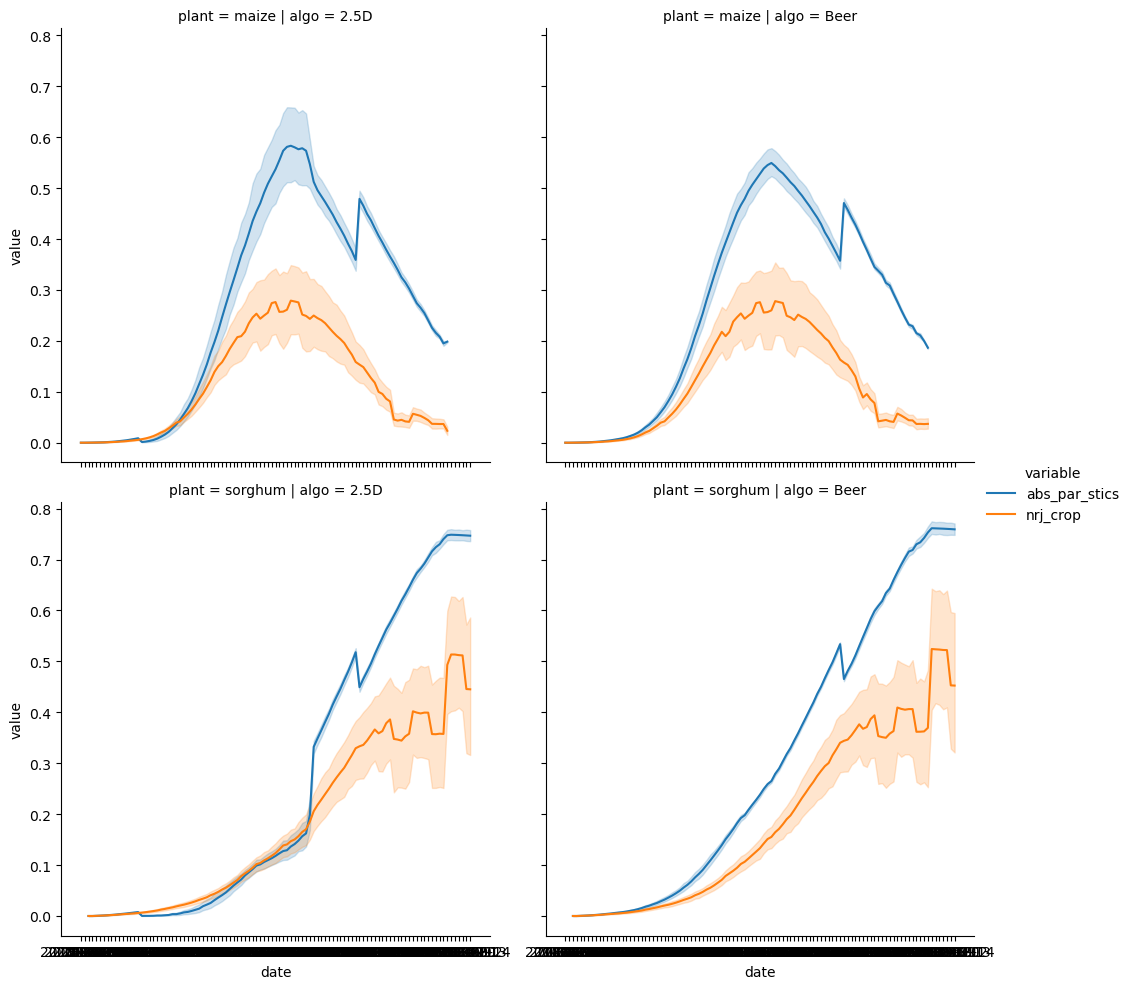

In [99]:
sns.relplot(
    data=long,
    x="date", # DOY
    y="value",
    hue="variable",
    row="plant",
    col="algo",
    kind="line",
)

# use get_figure function and store the plot i
# n a variable (scatter_fig)
scatter_fig = scatter_plot.get_figure()

# use savefig function to save the plot and give
# a desired name to the plot.
scatter_fig.savefig('scatterplot.png')

In [ ]:
long = df.melt(
    id_vars=["usm", "algo", "plant", "id", "date"],
    value_vars=["abs_par_stics", "nrj_crop"], 
    # var_name="variable",
    # value_name="value",
)

long

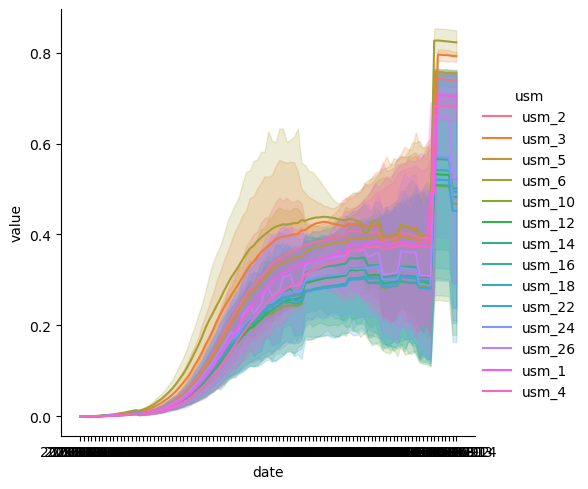

In [16]:
sns.relplot(
    data=long,
    x="date", # DOY
    y="value",
    hue="usm",
    # row="plant",
    # col="algo",
    kind="line",
)

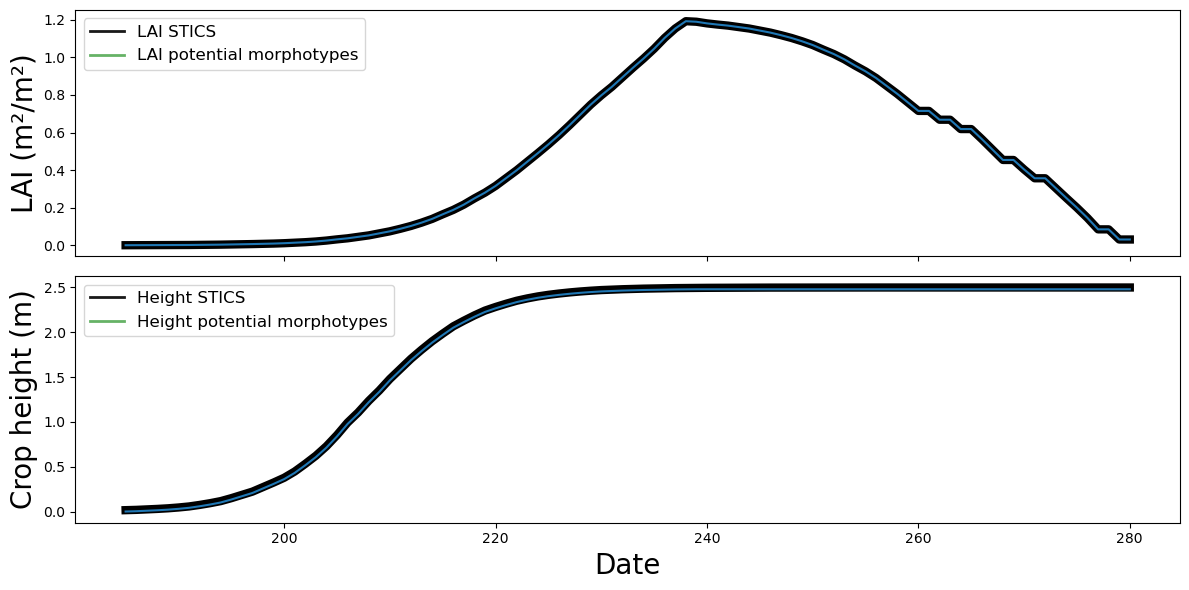

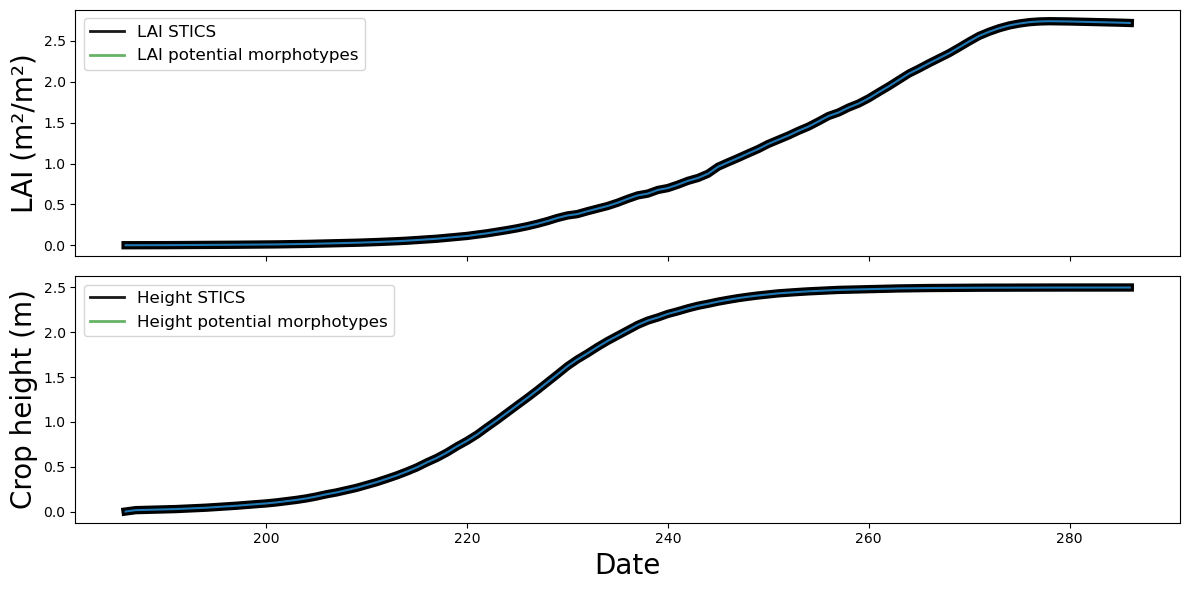

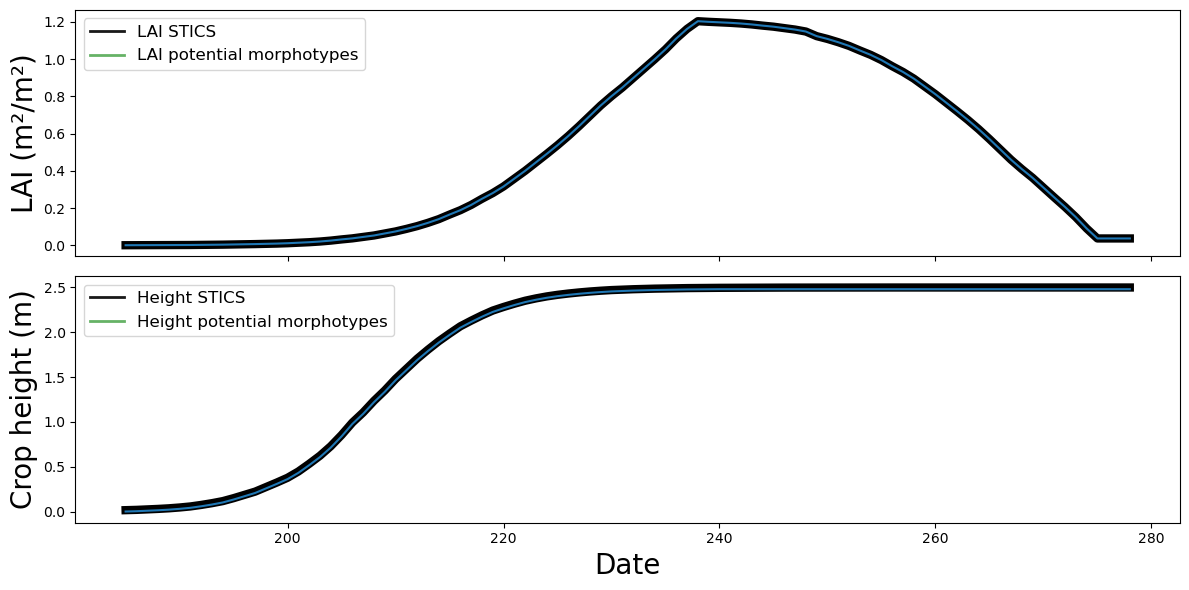

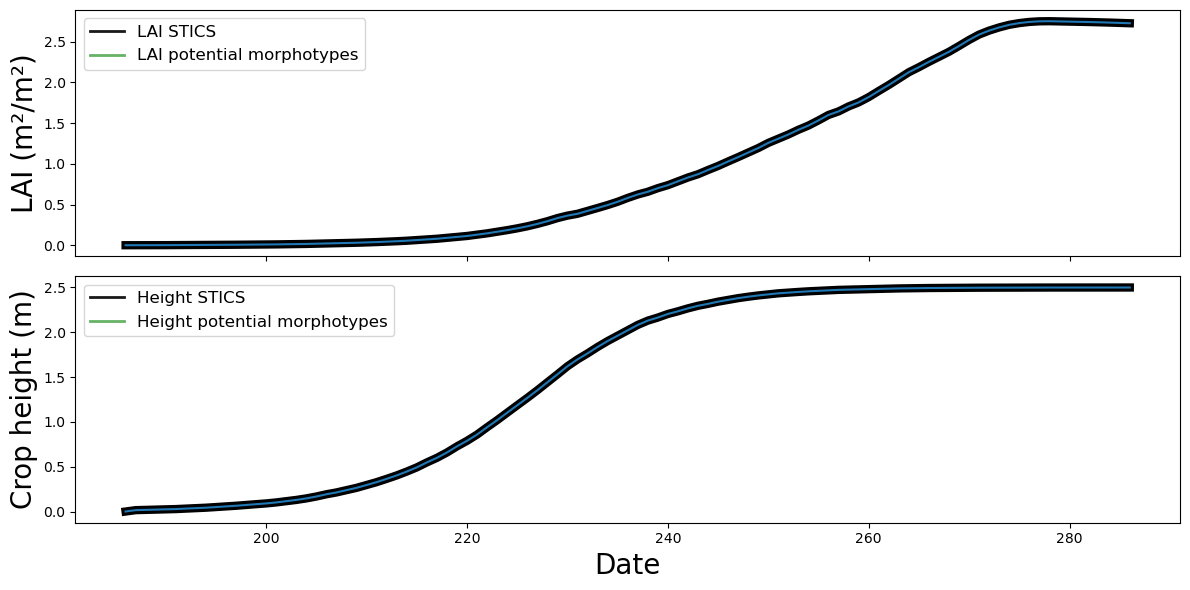

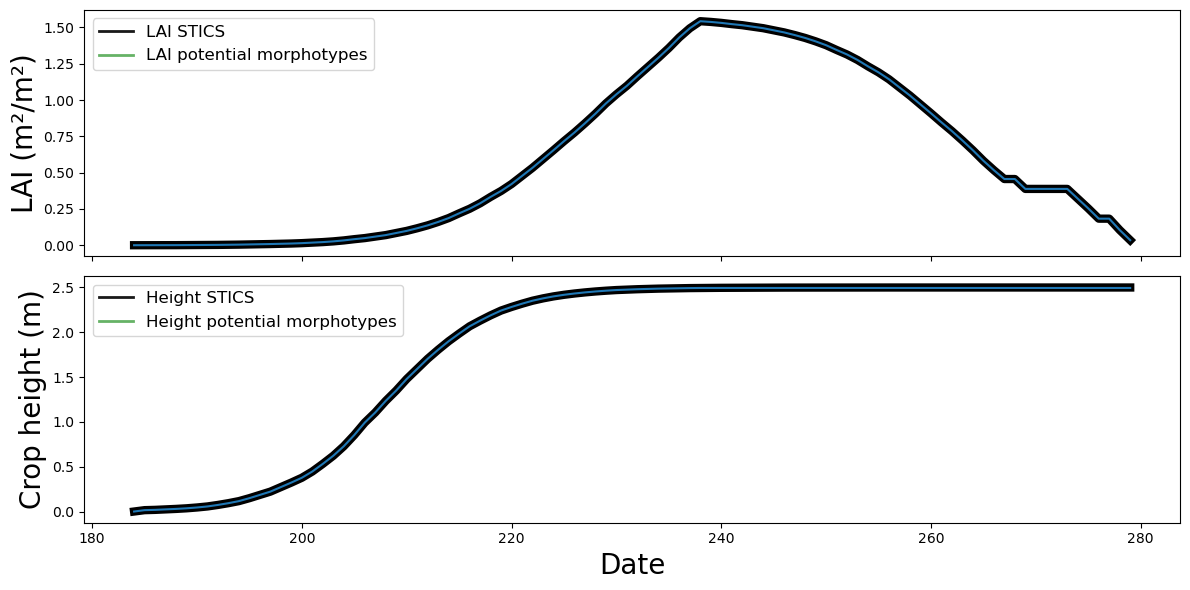

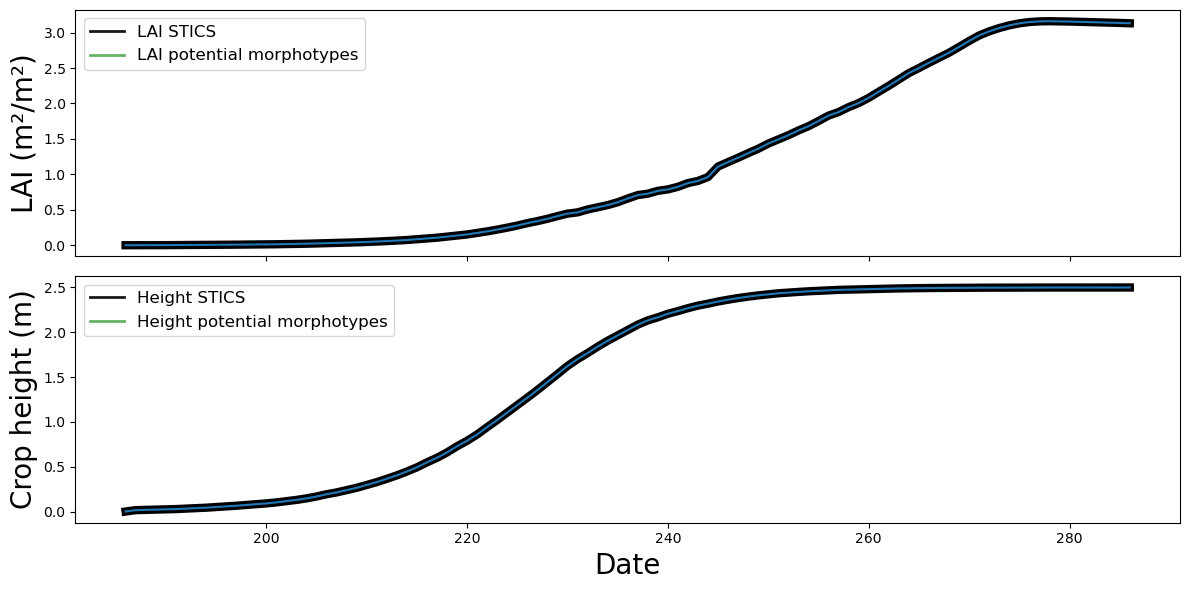

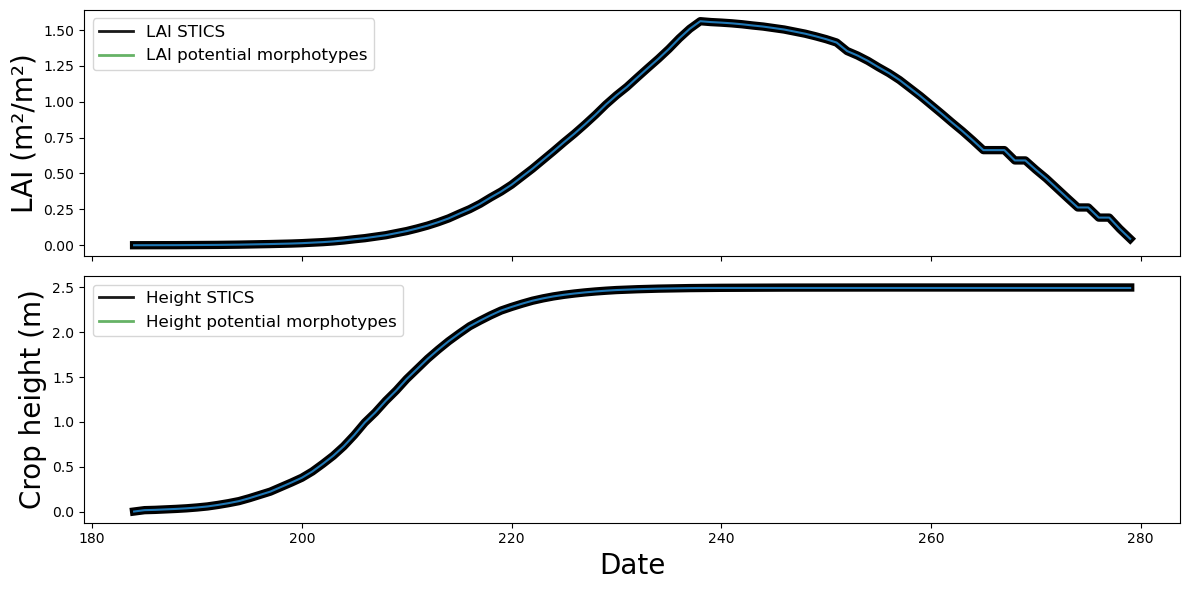

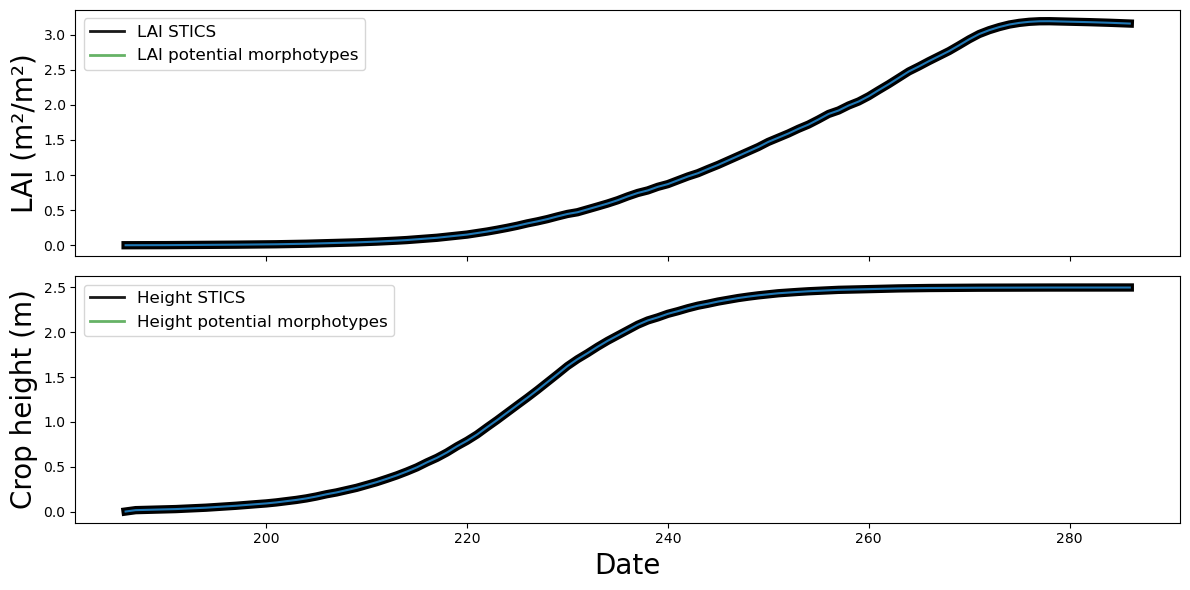

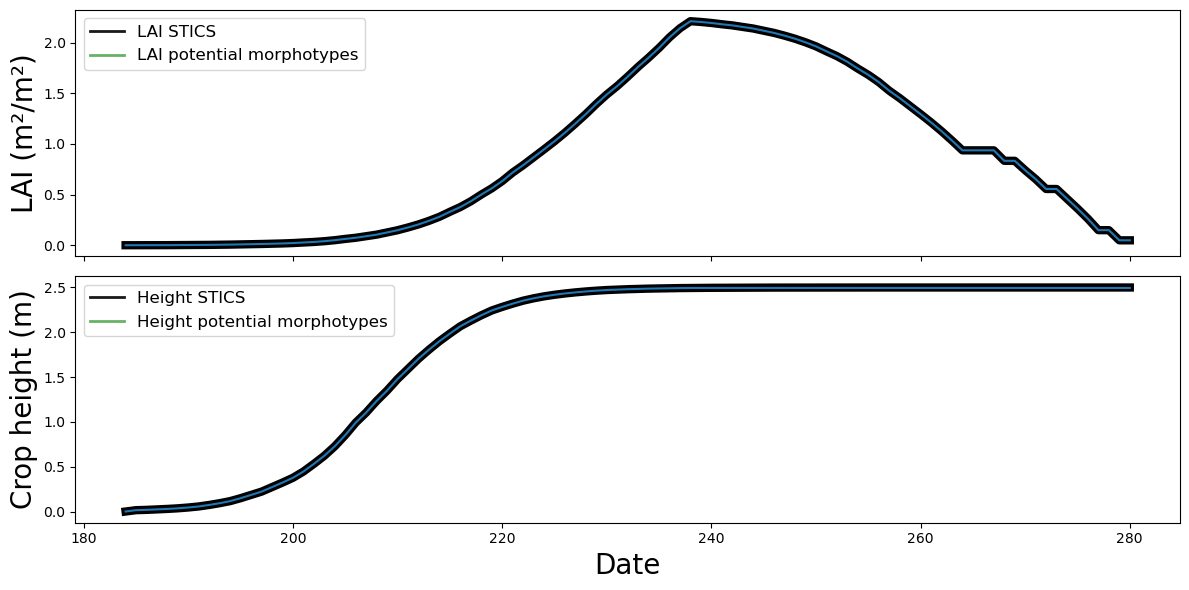

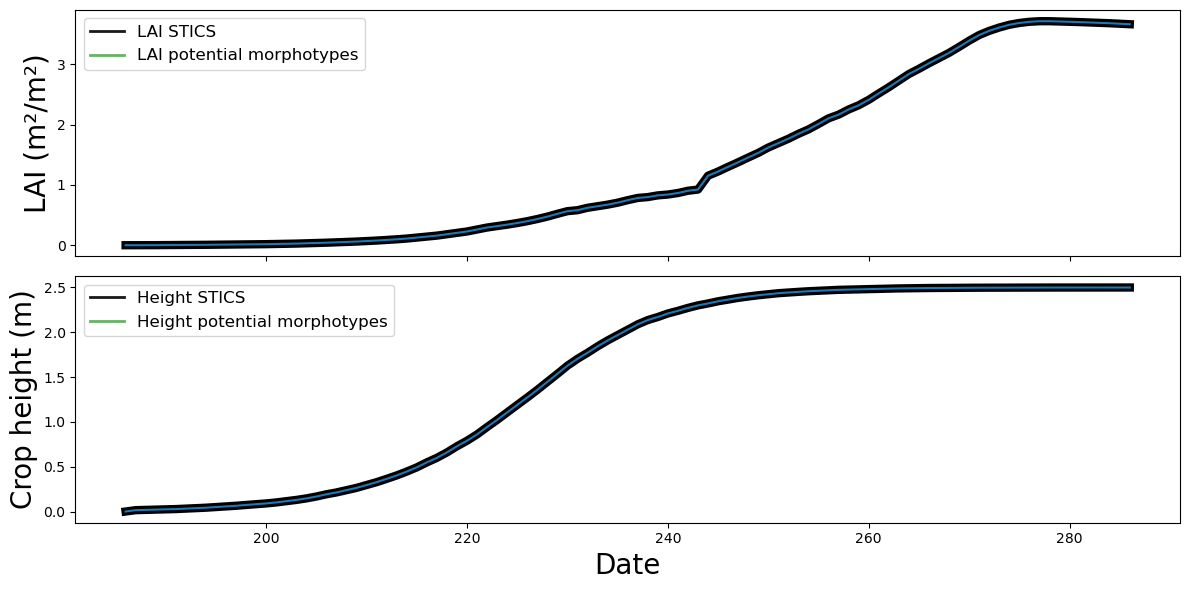

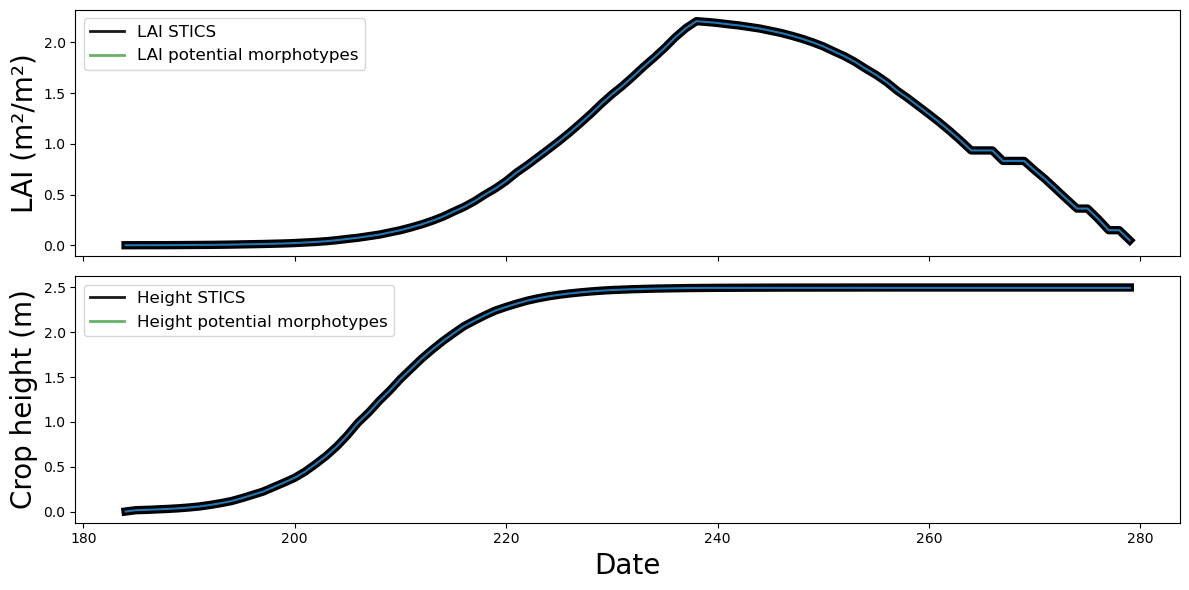

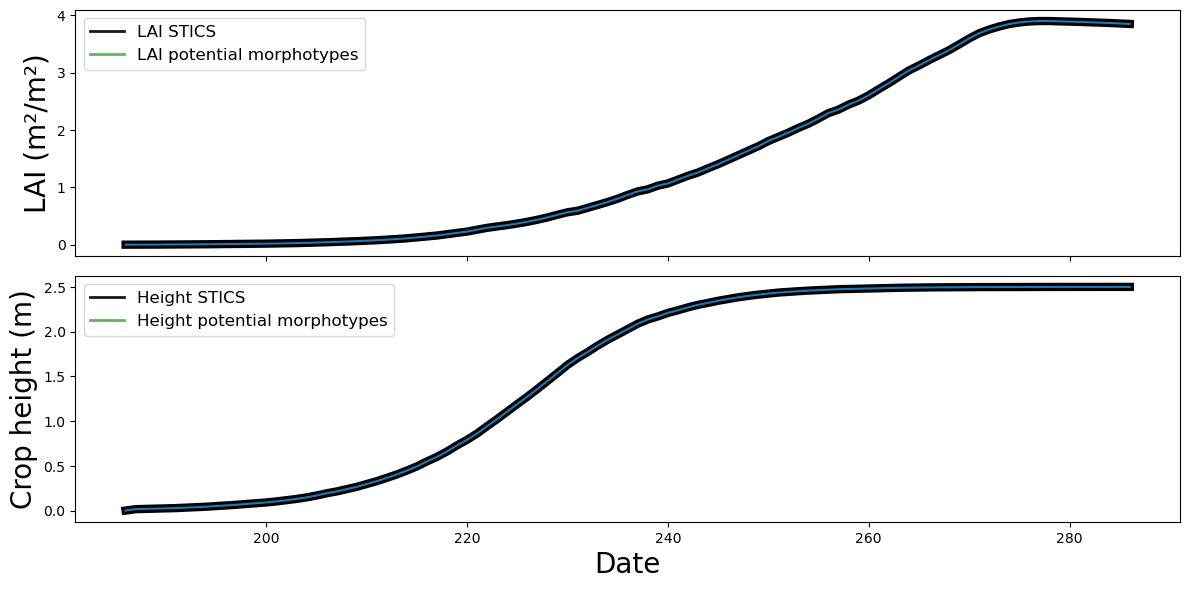

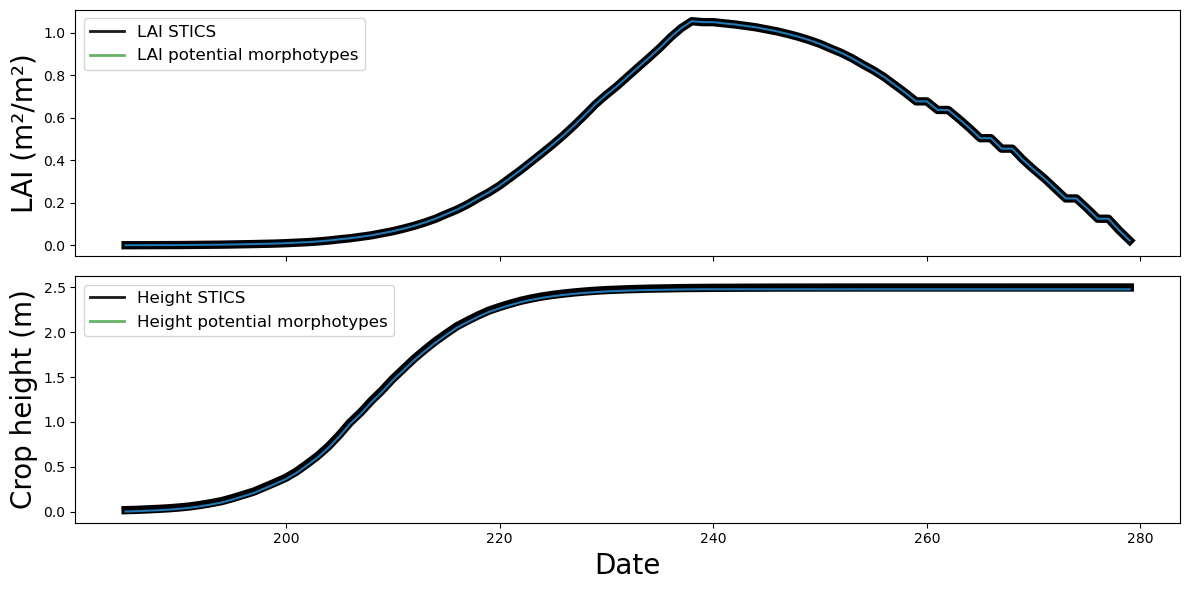

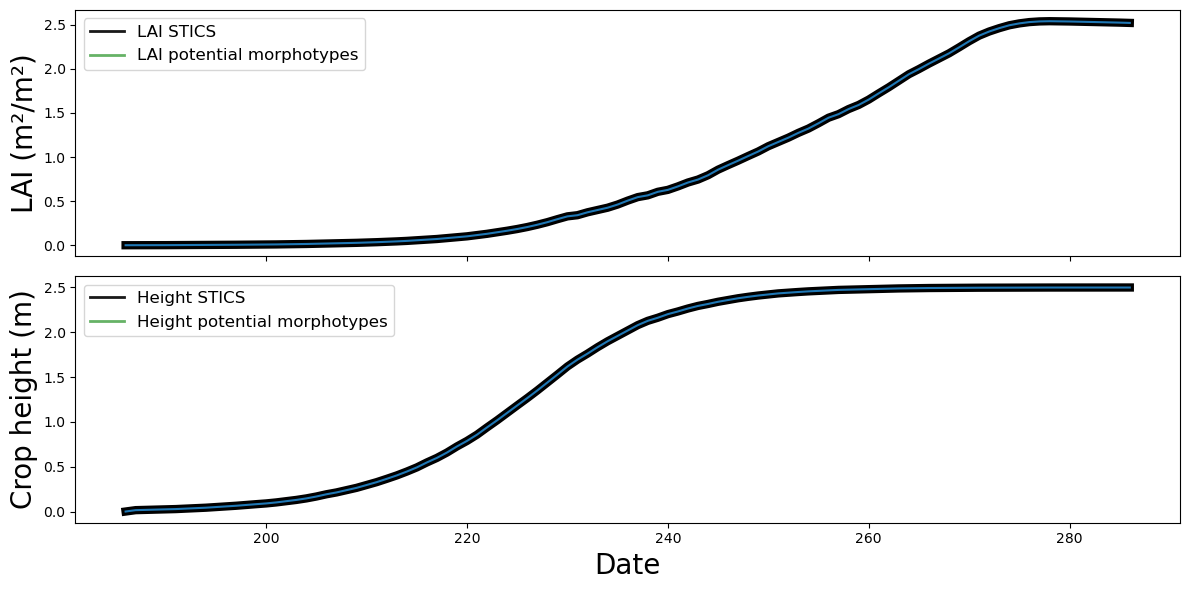

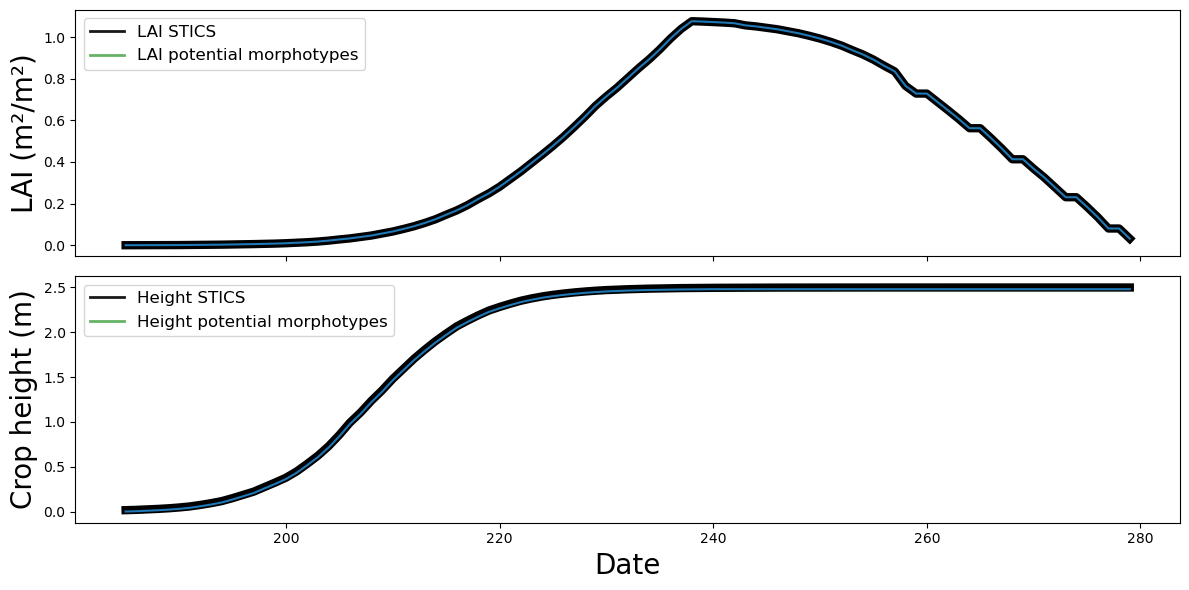

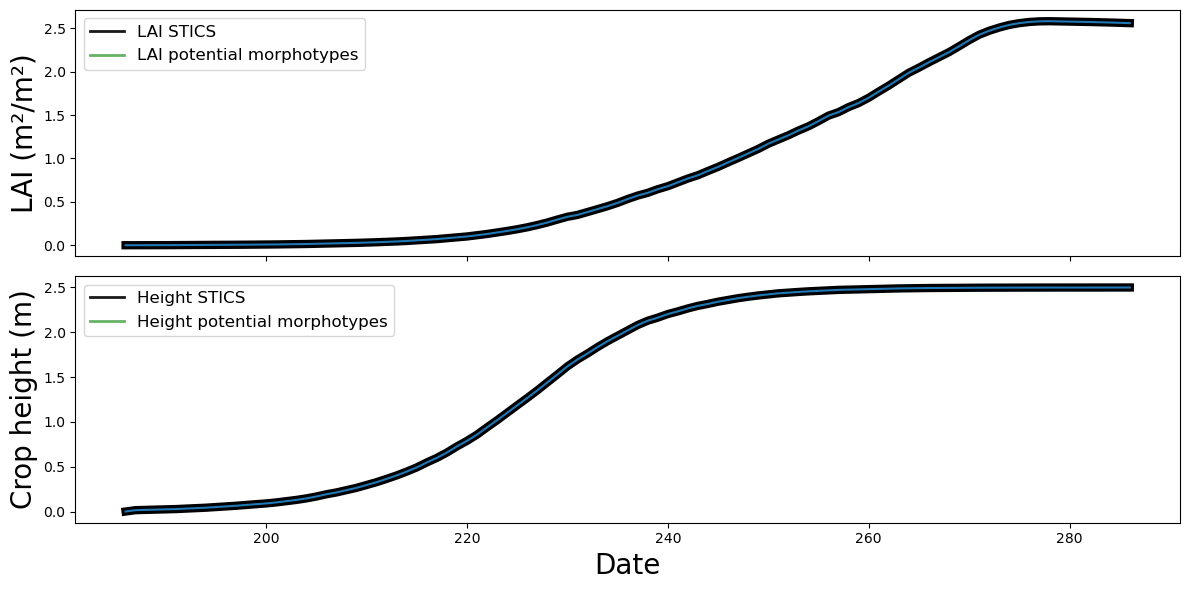

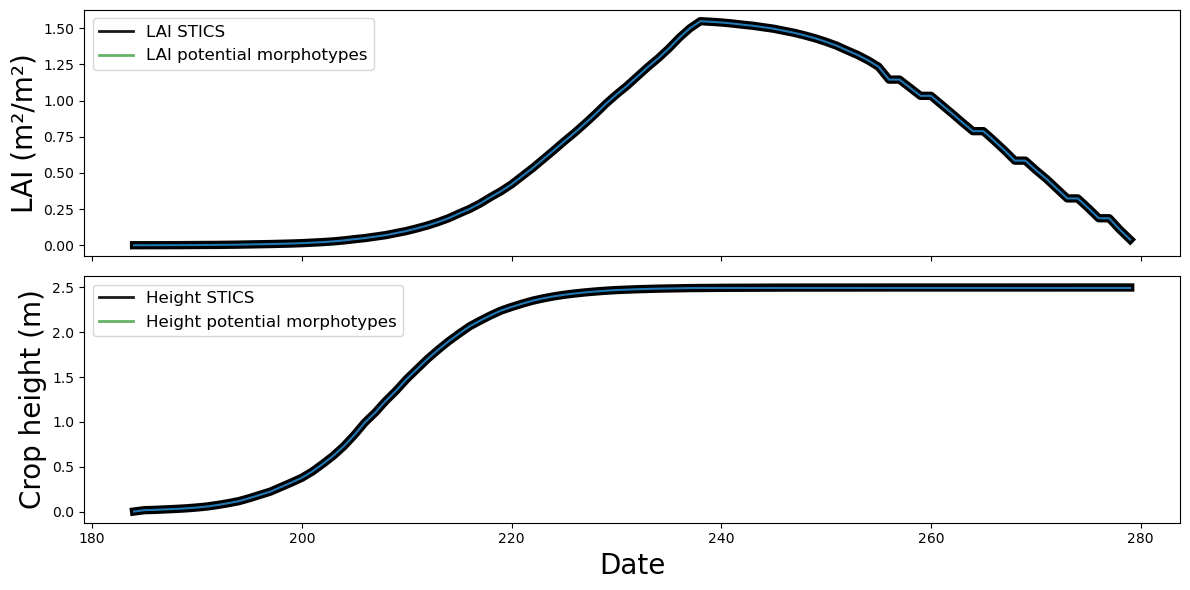

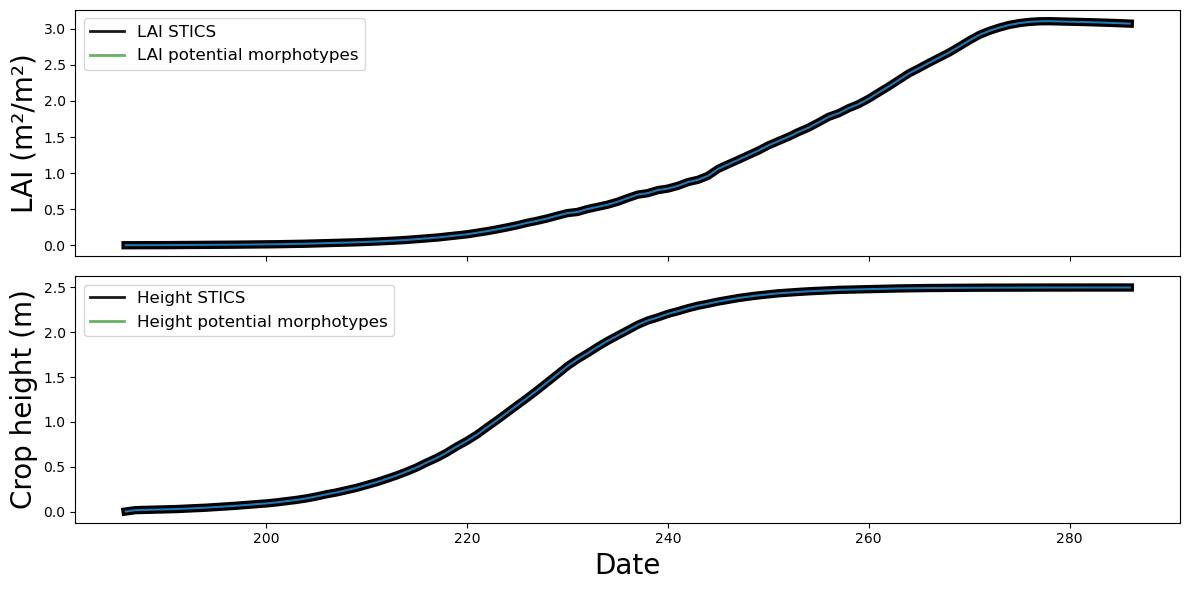

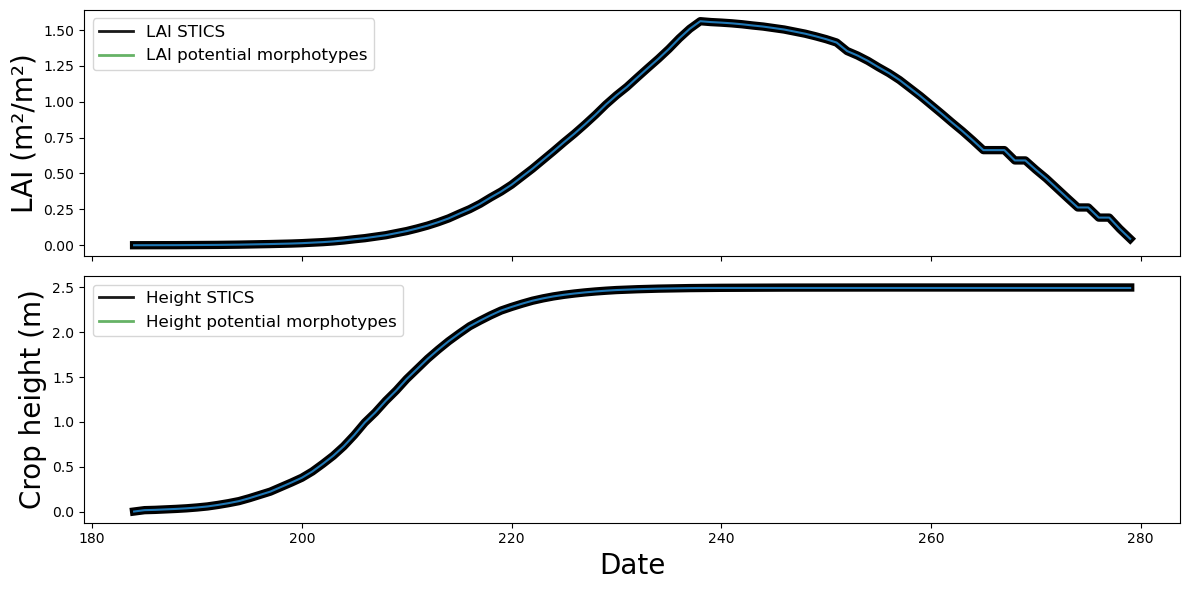

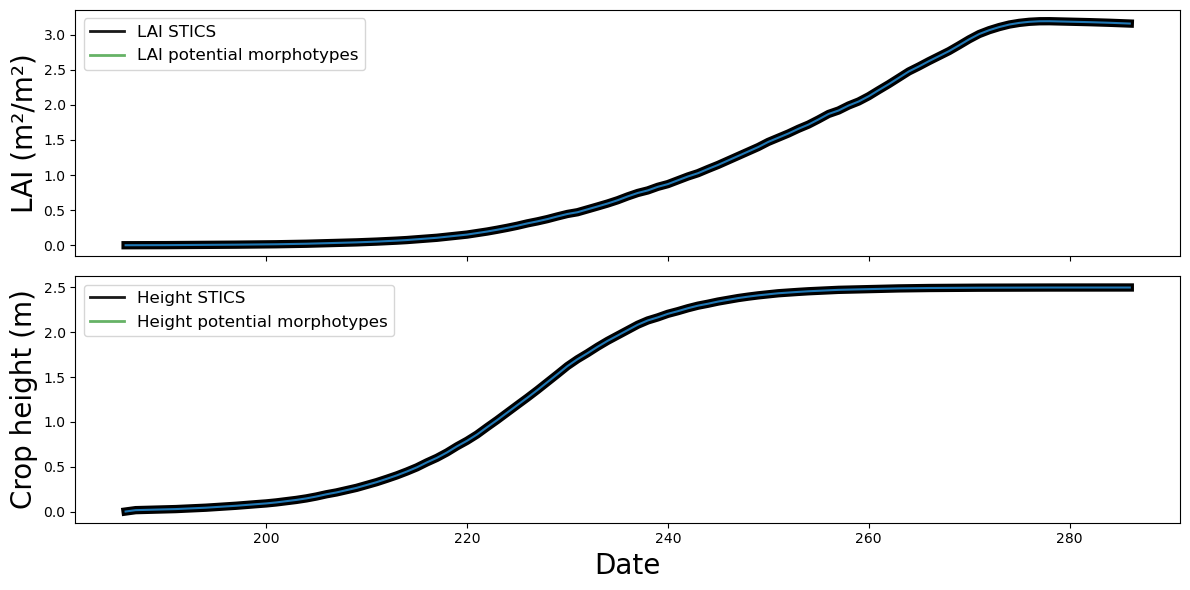

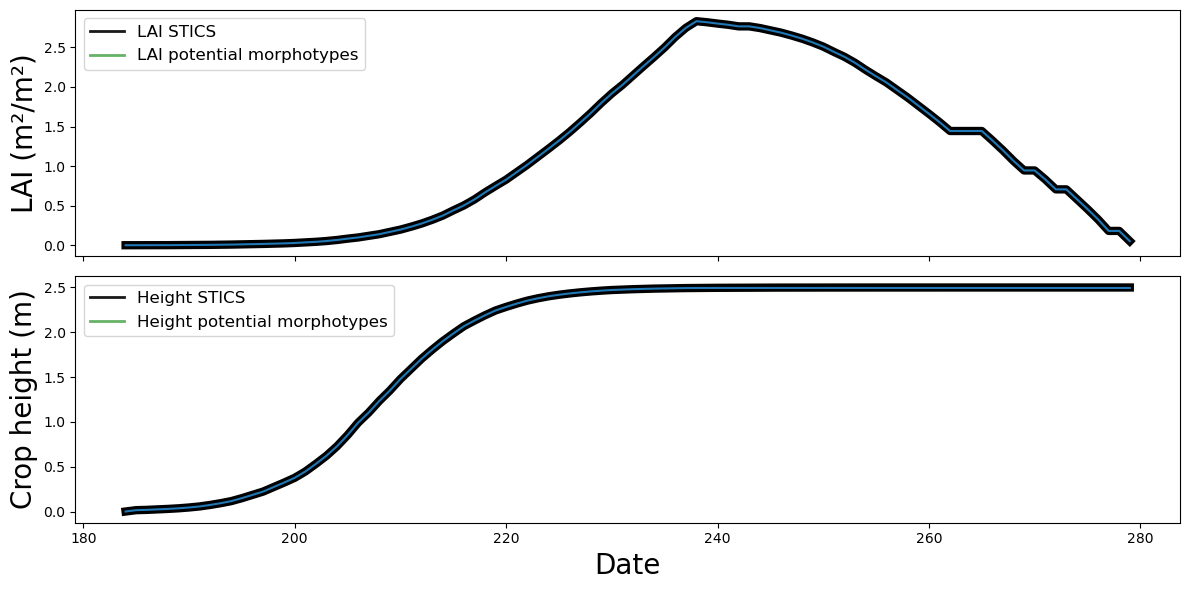

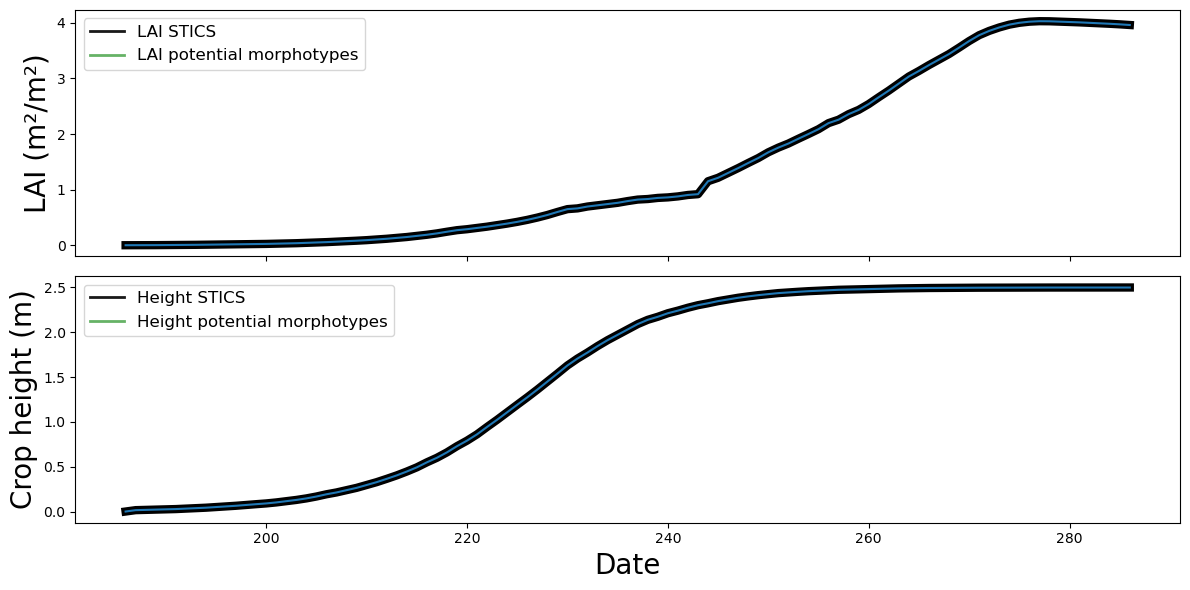

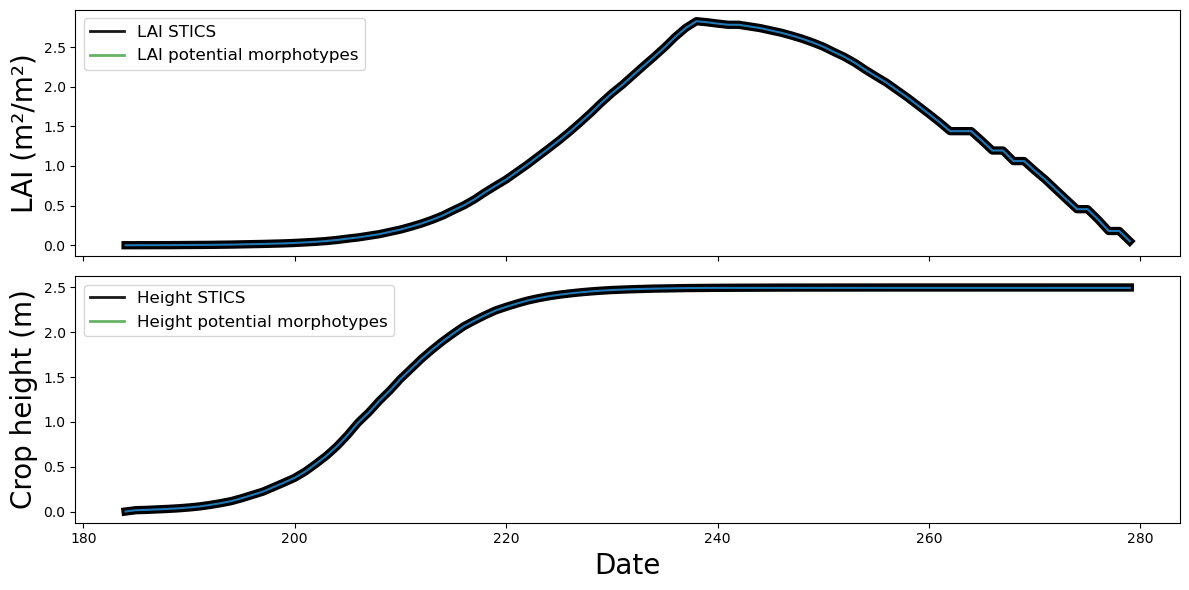

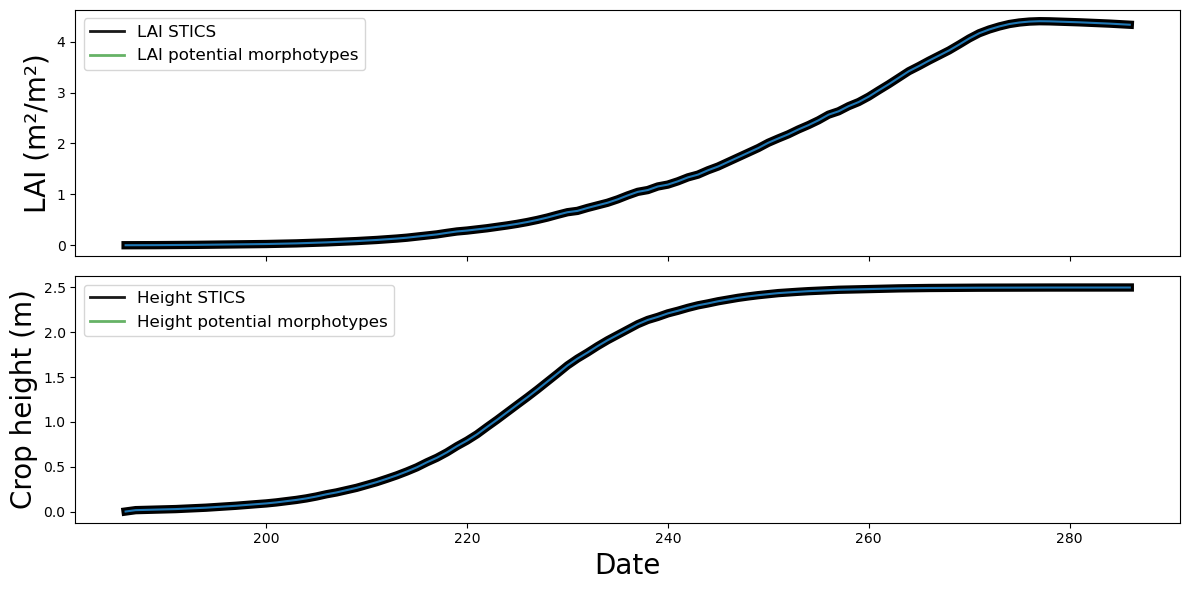

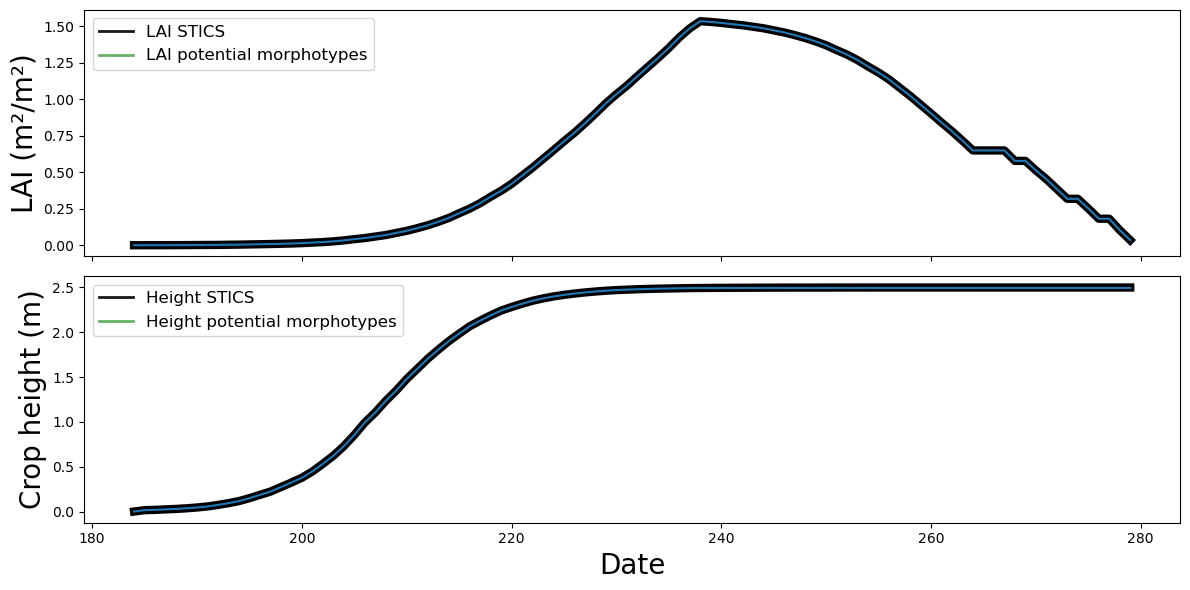

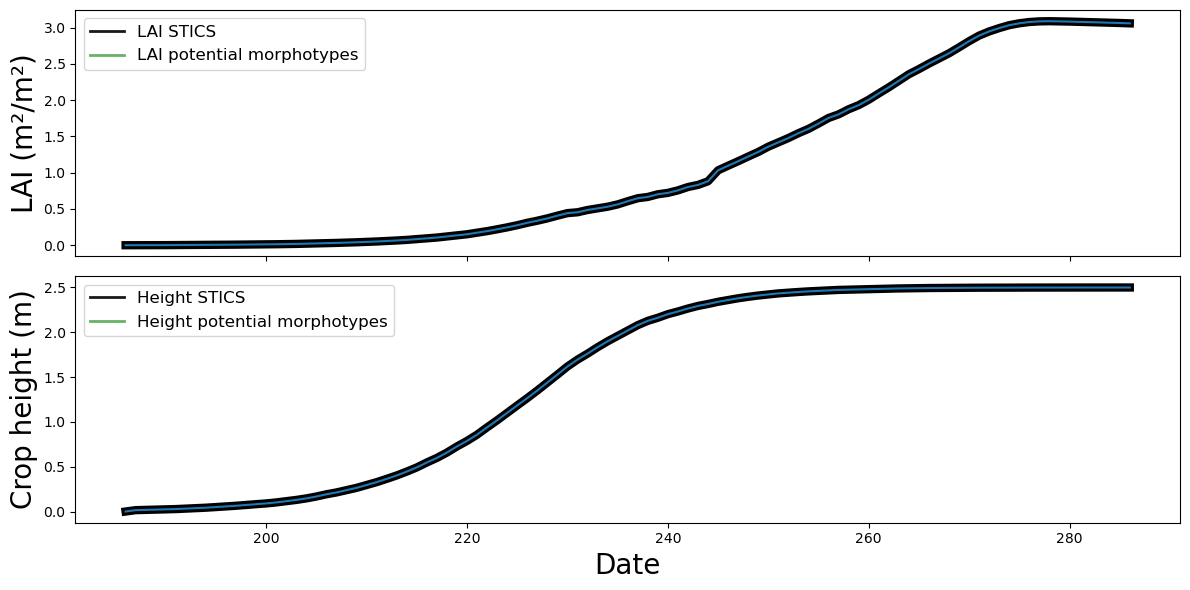

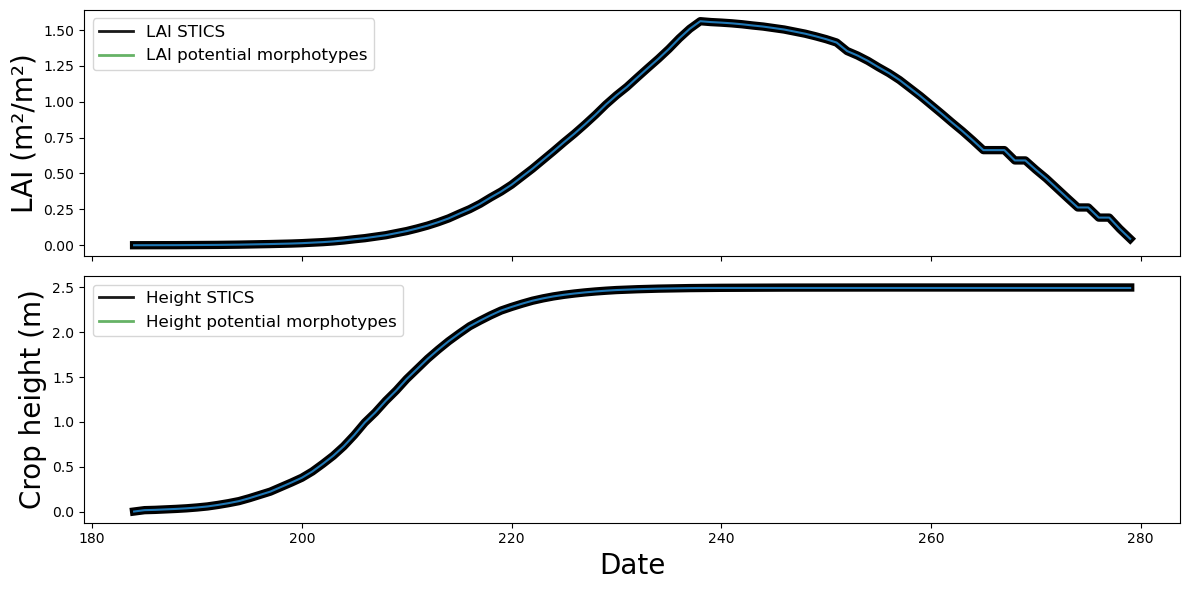

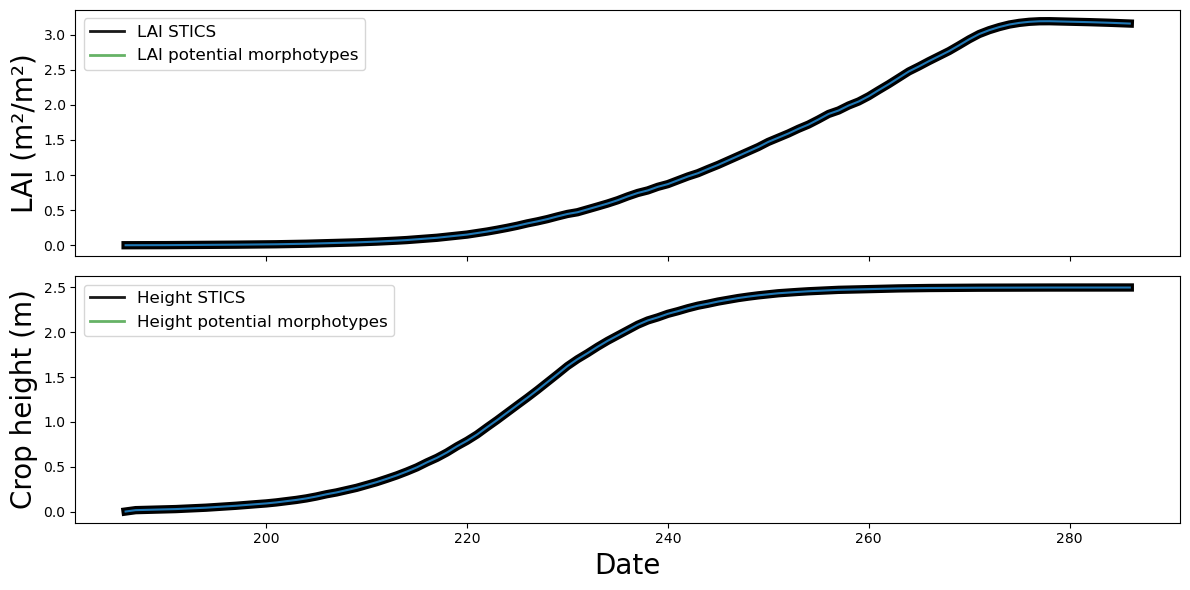

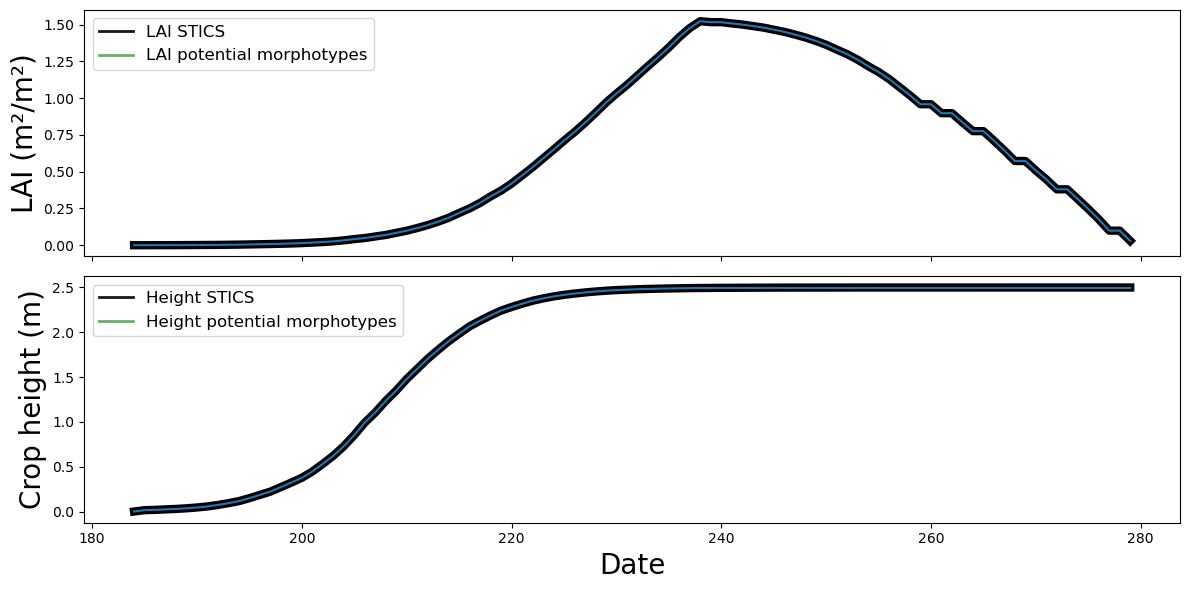

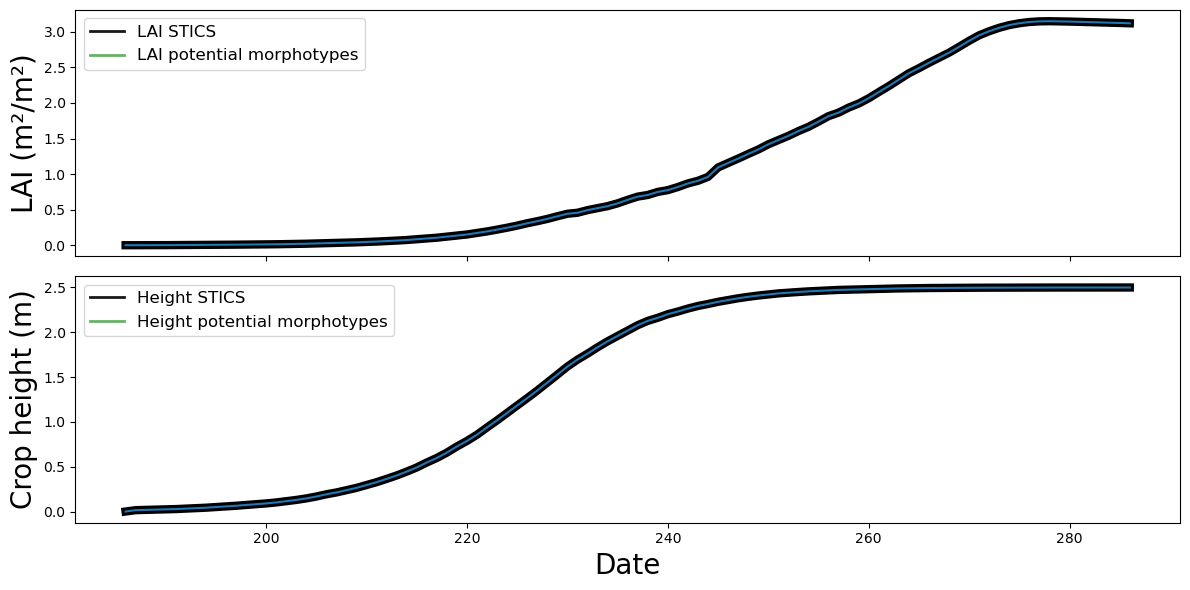

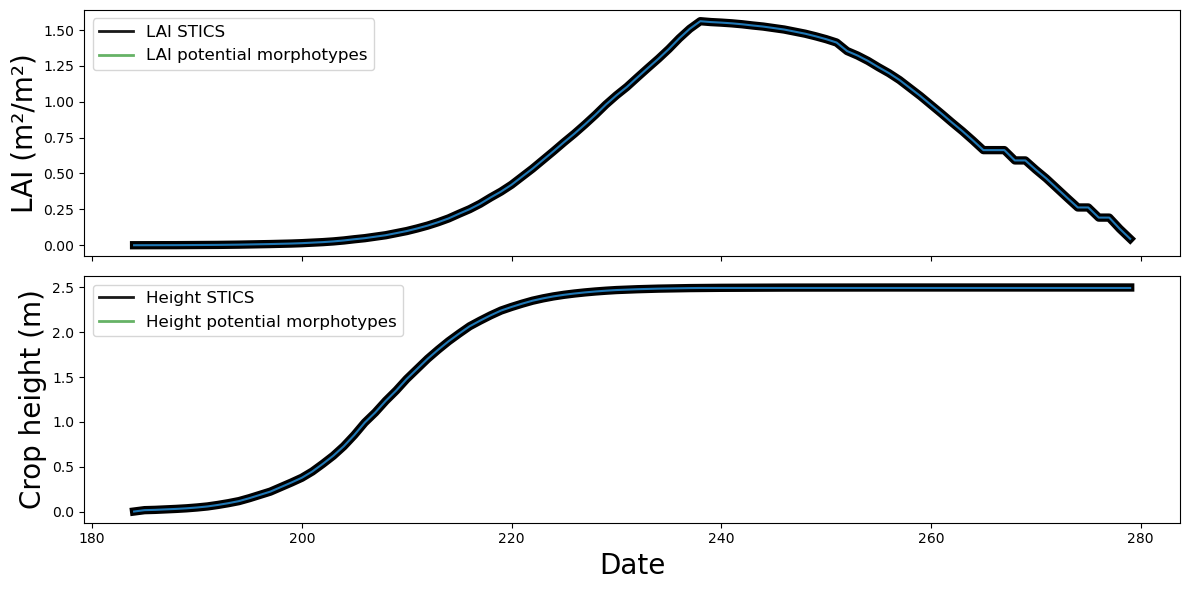

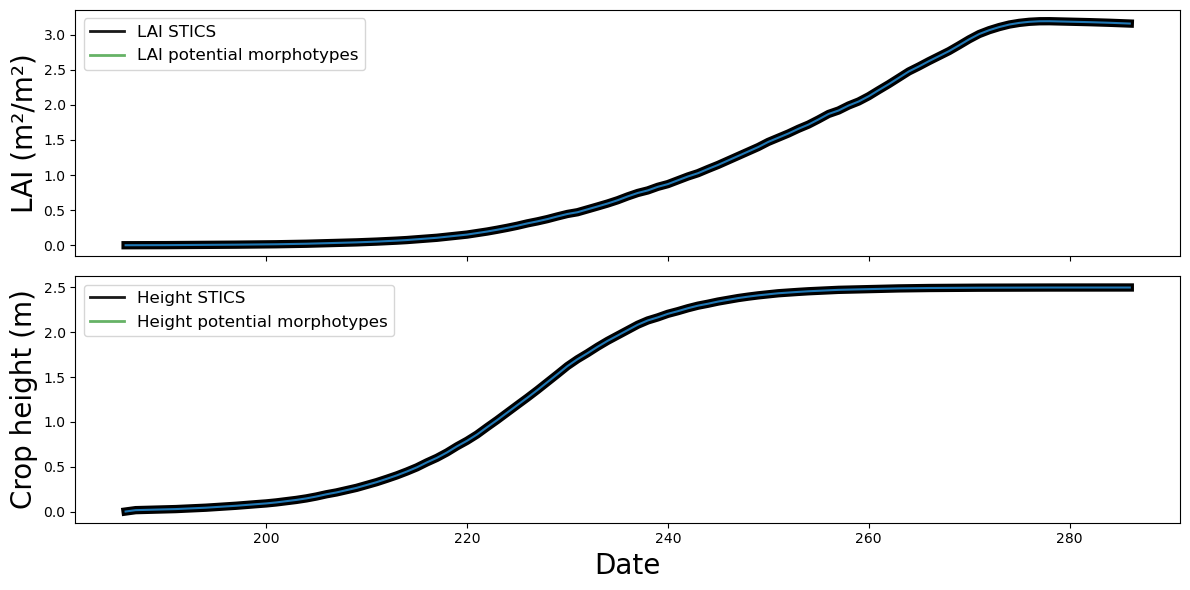

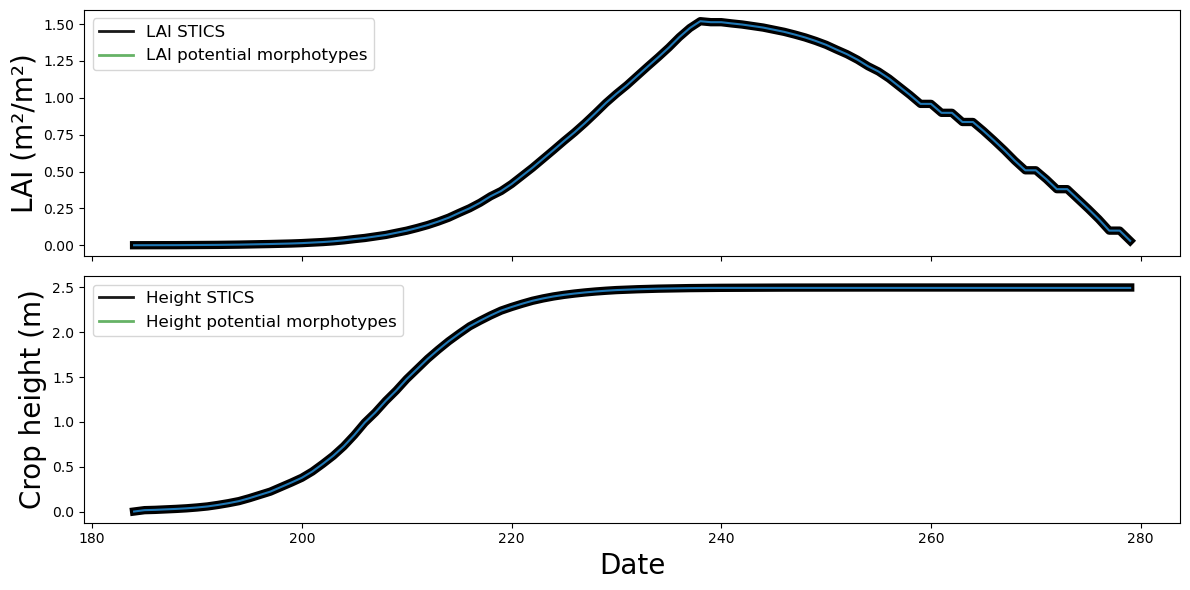

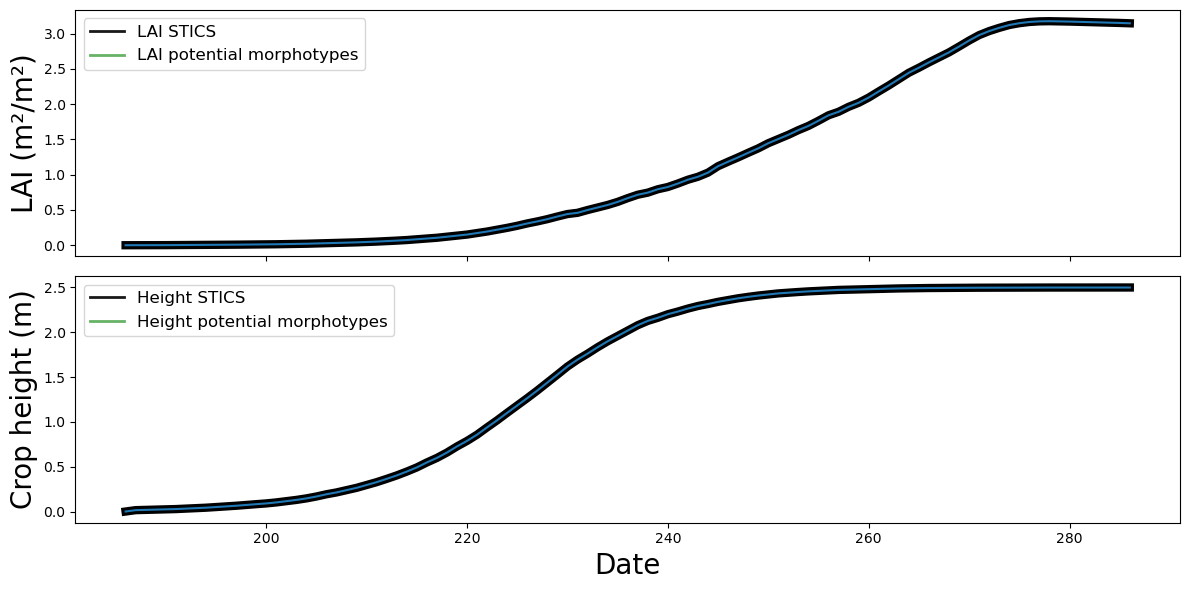

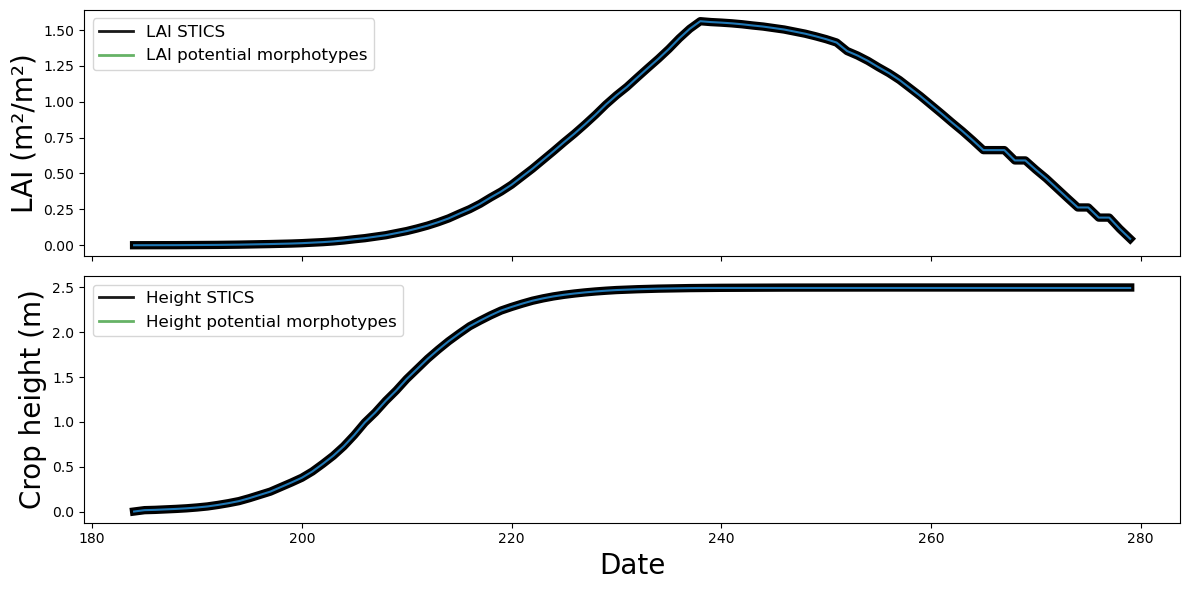

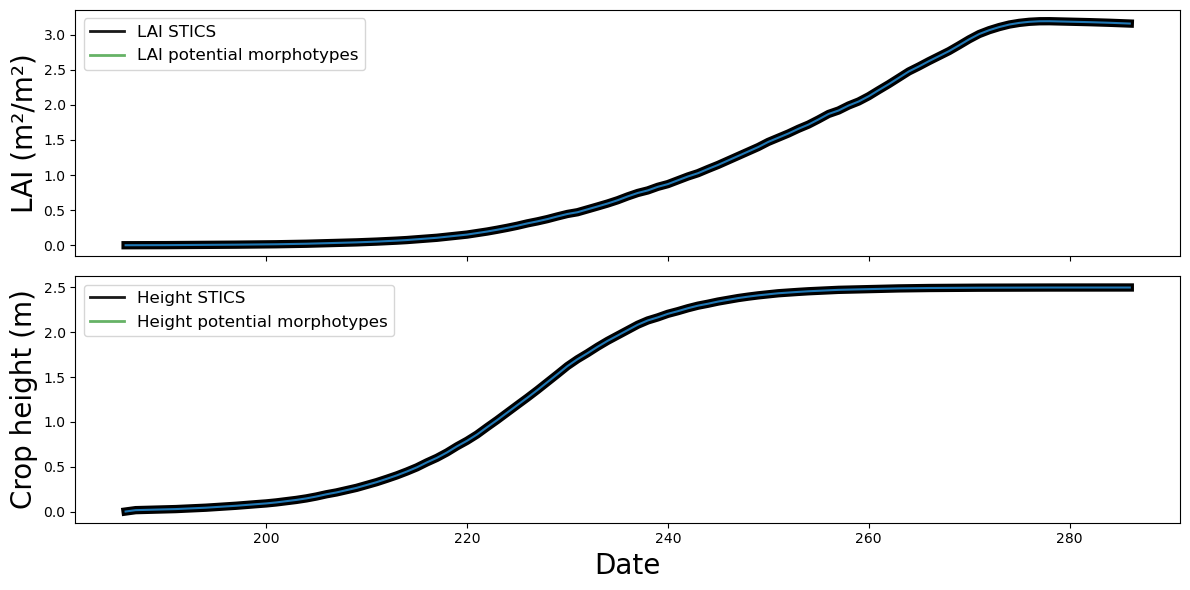

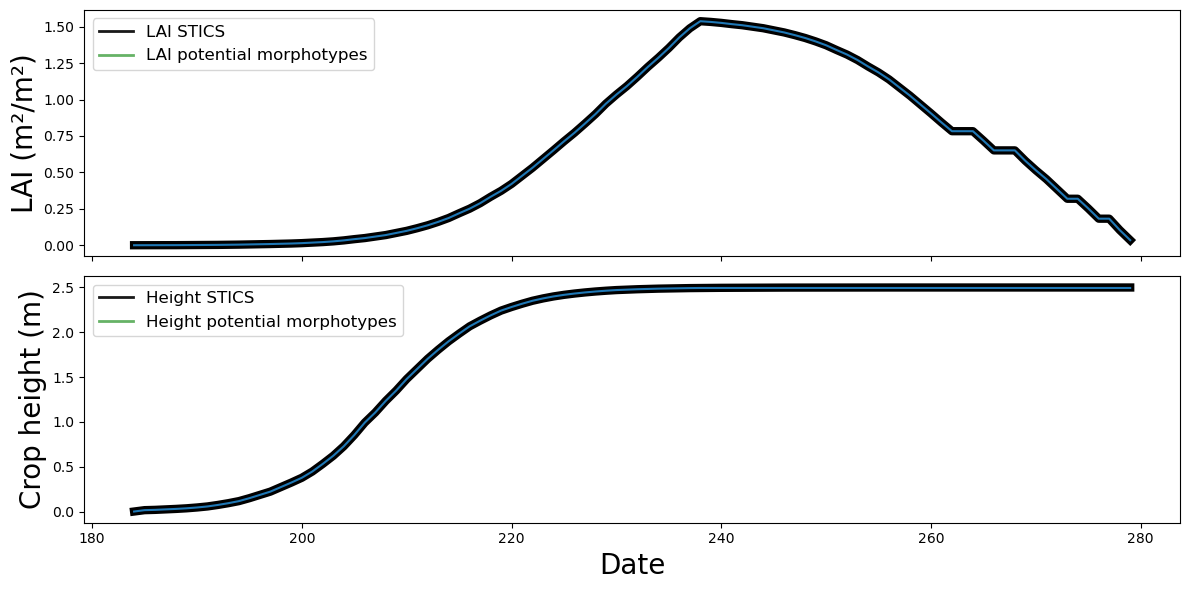

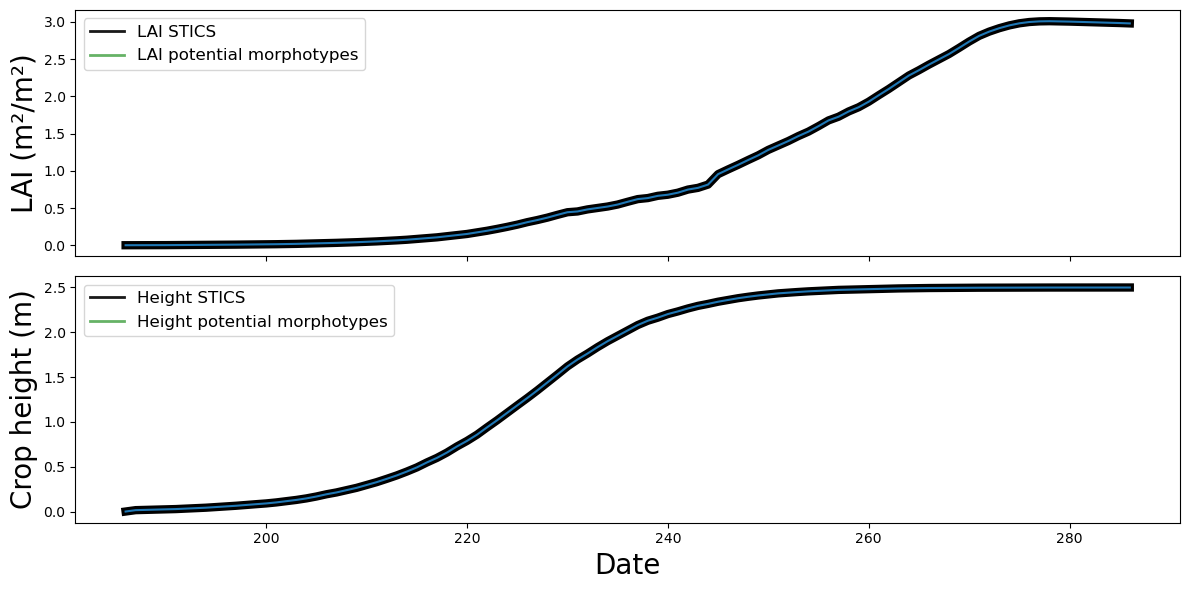

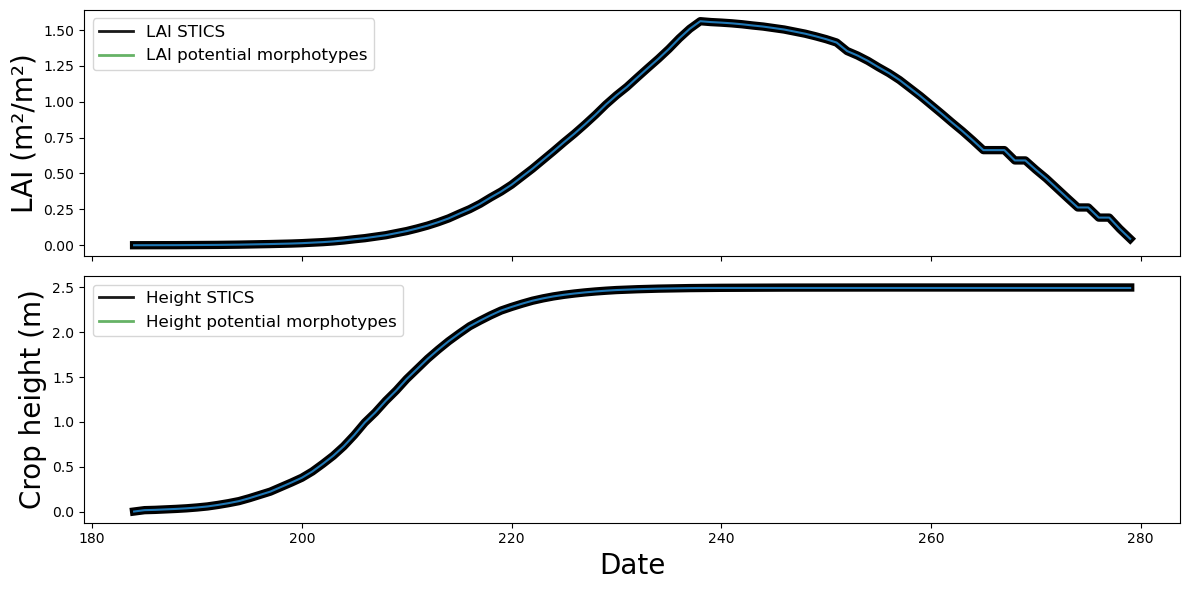

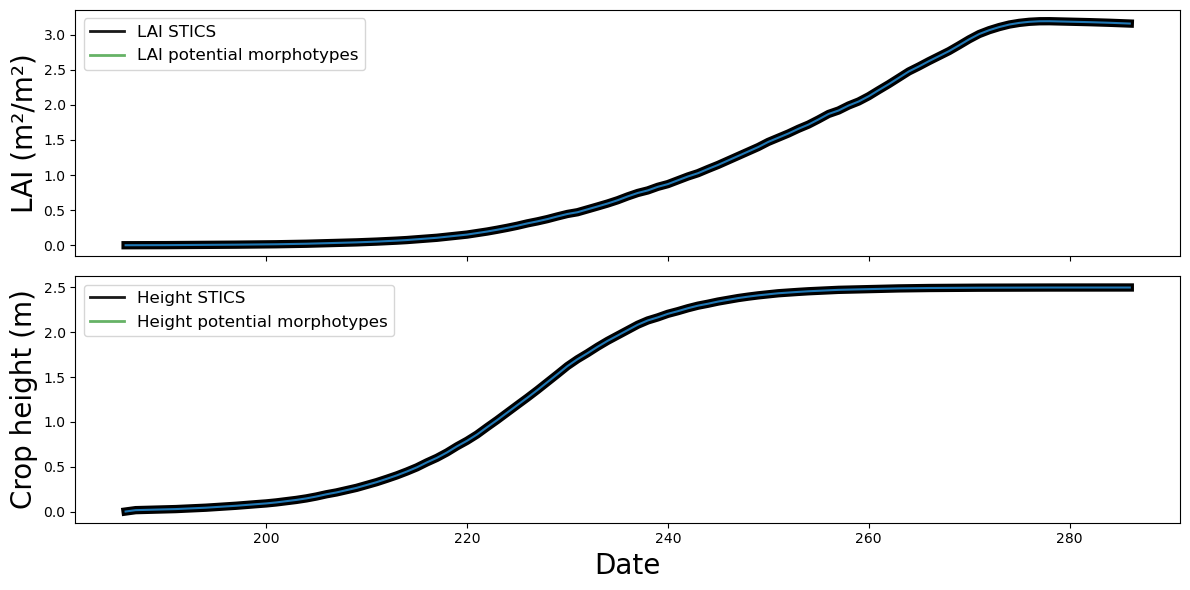

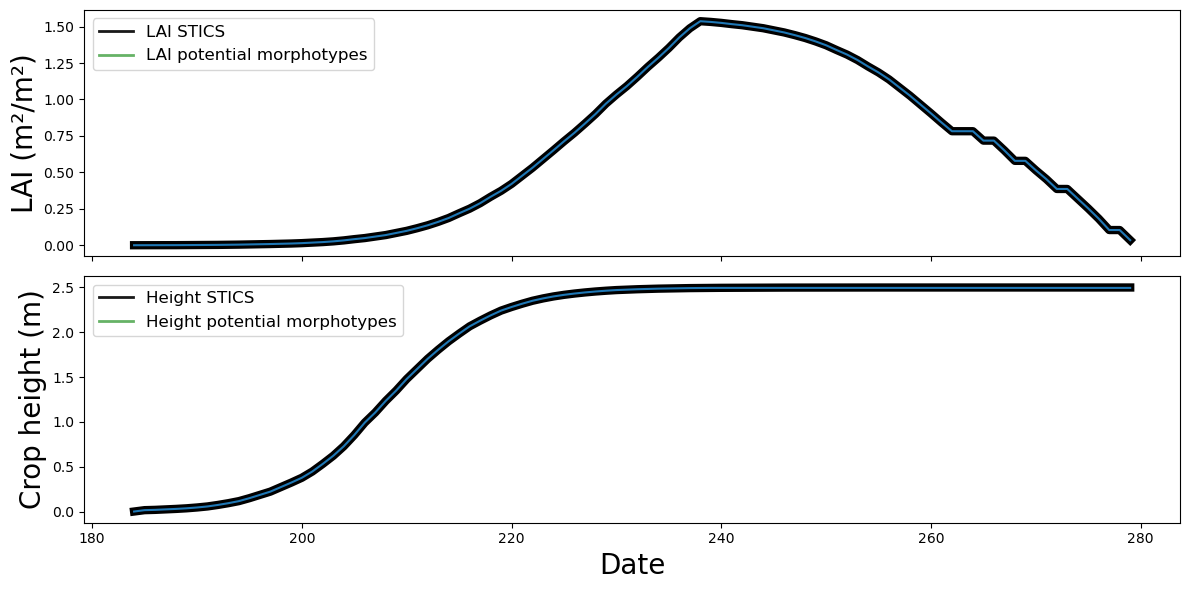

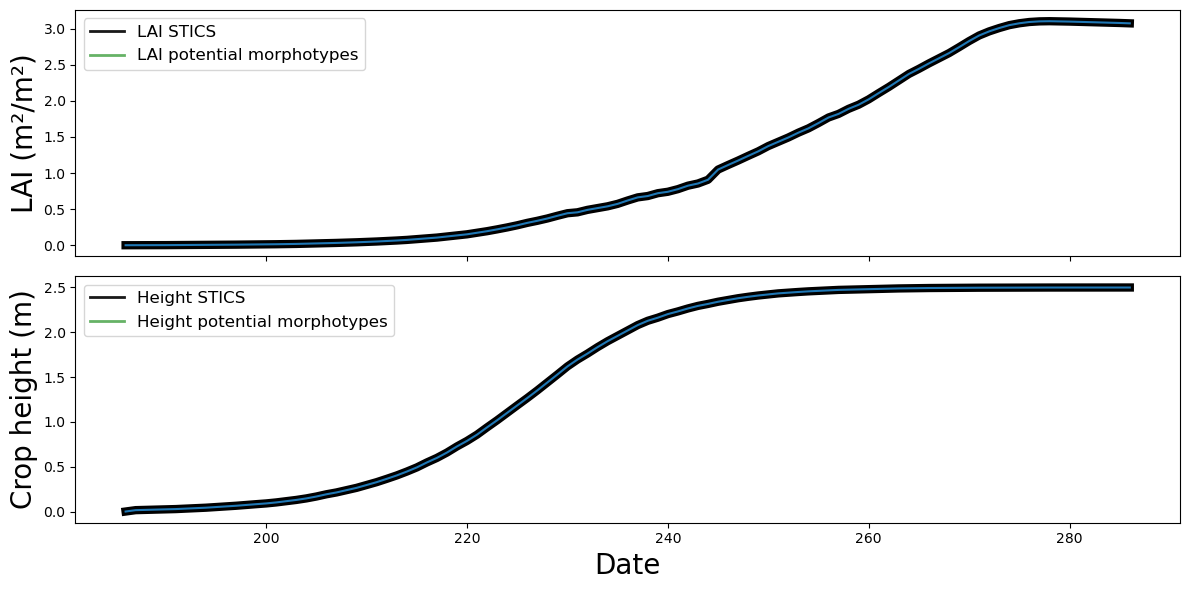

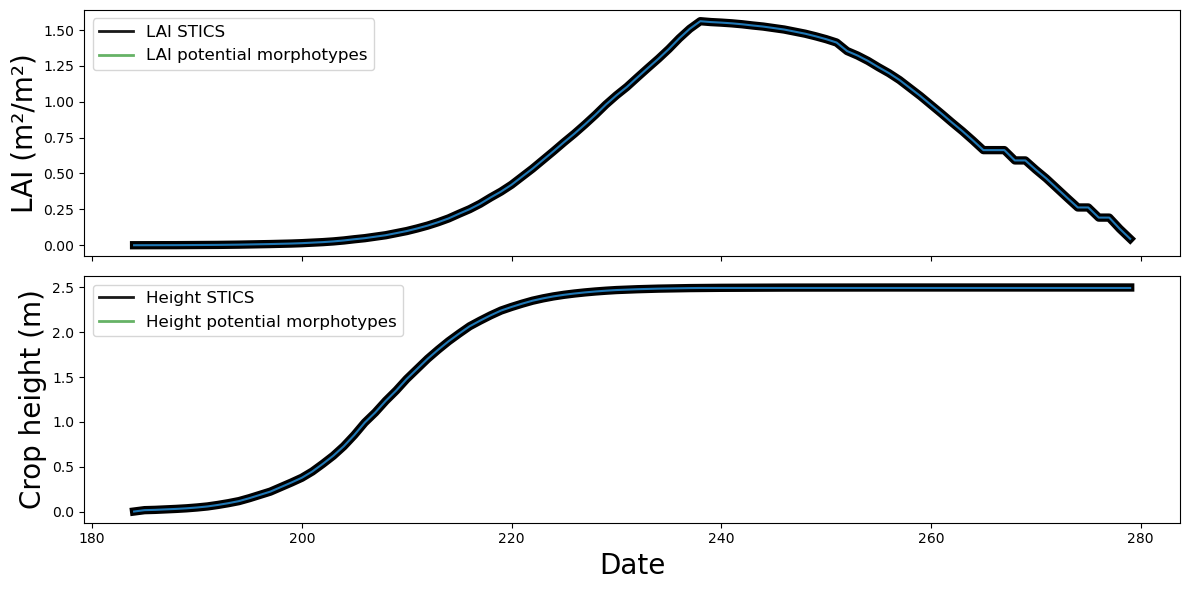

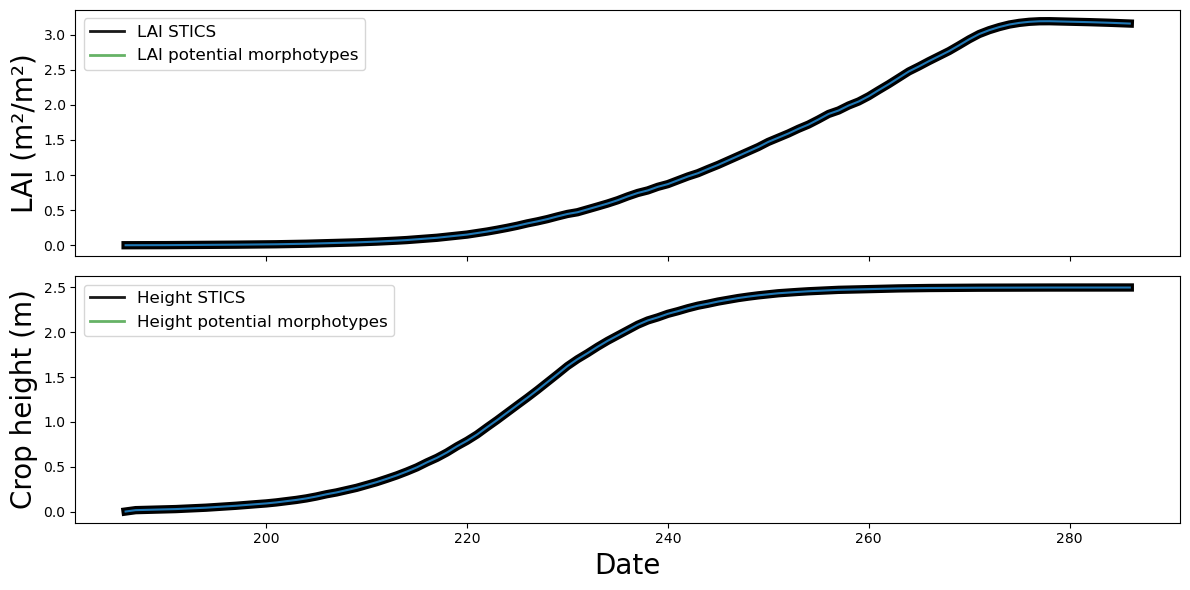

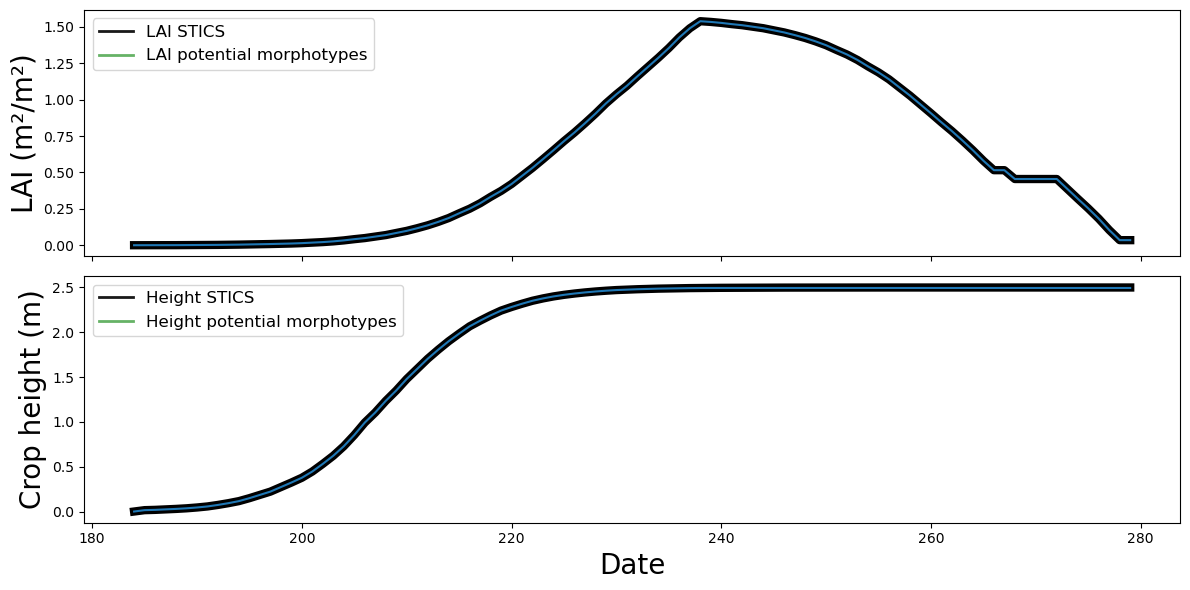

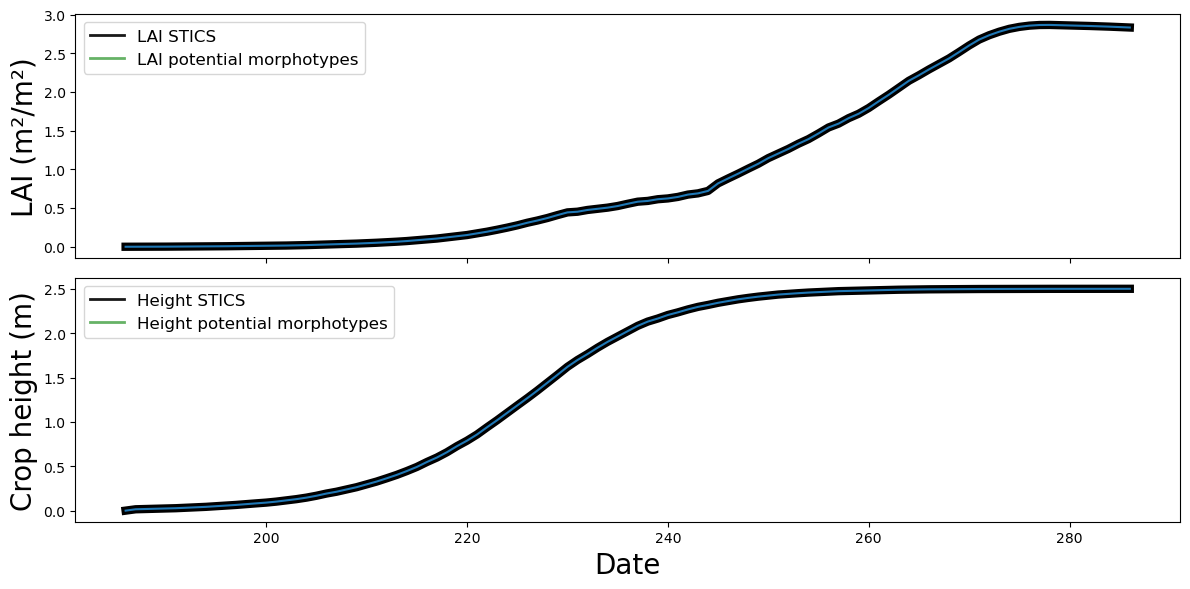

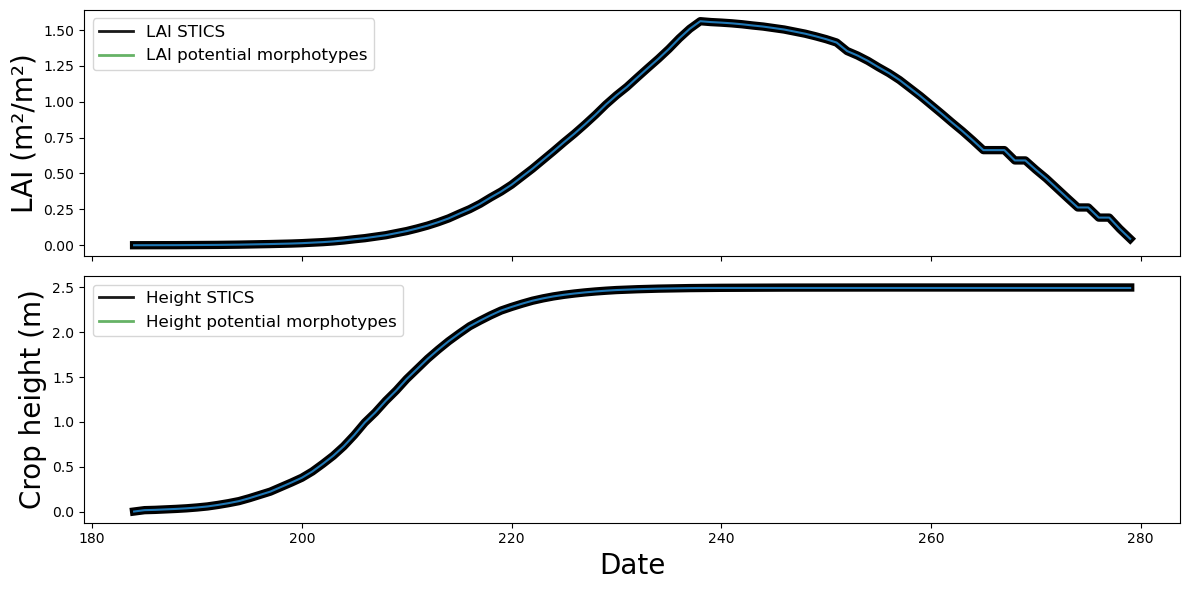

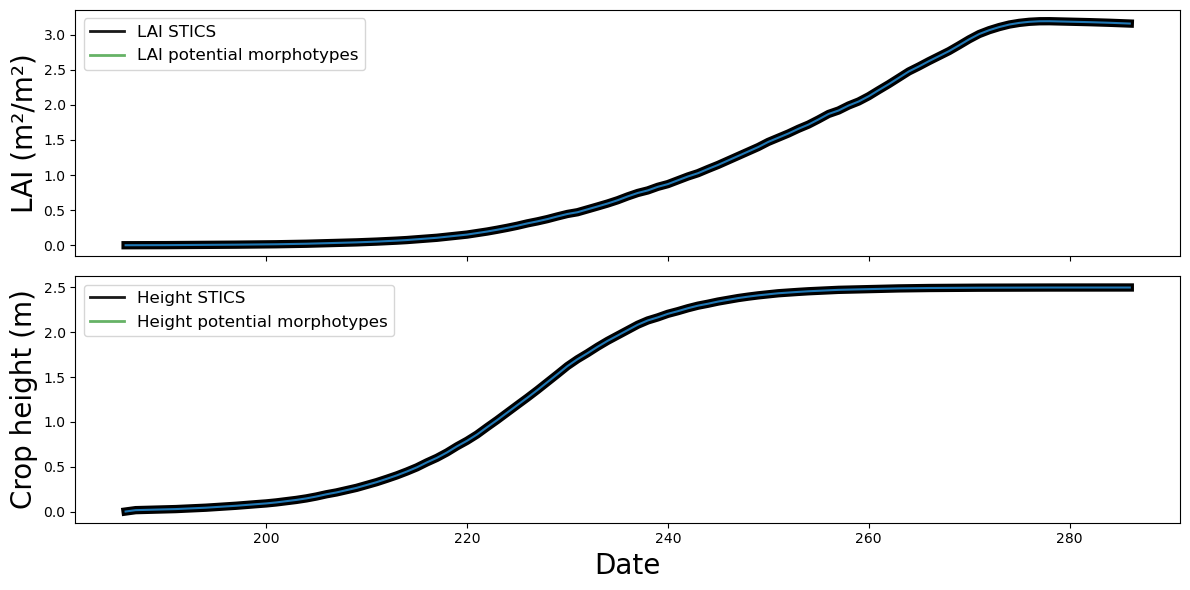

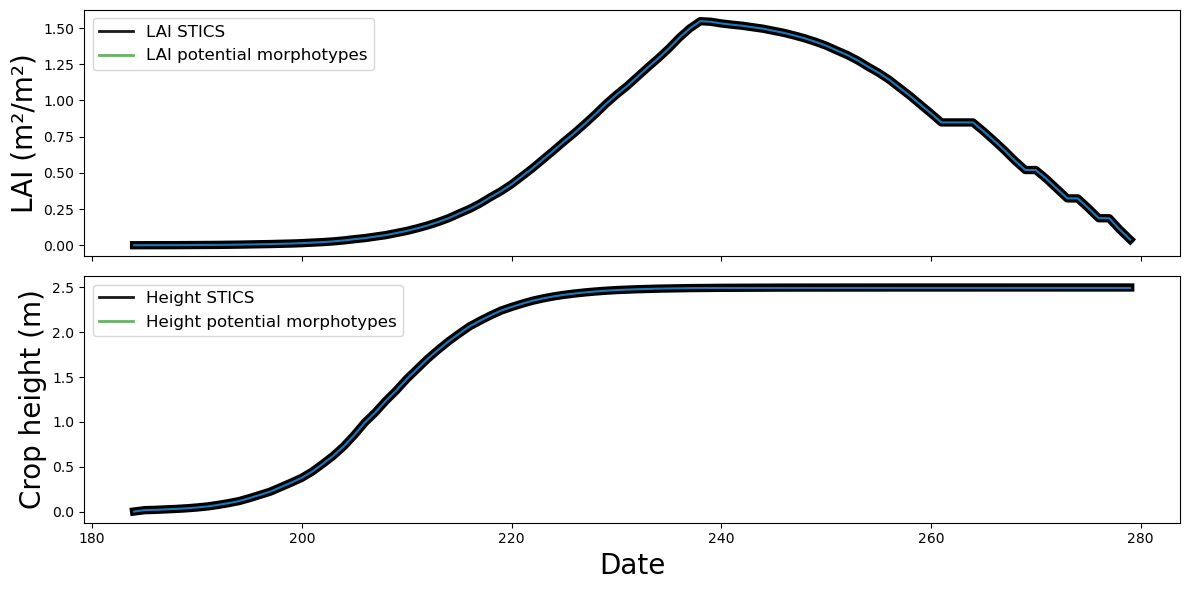

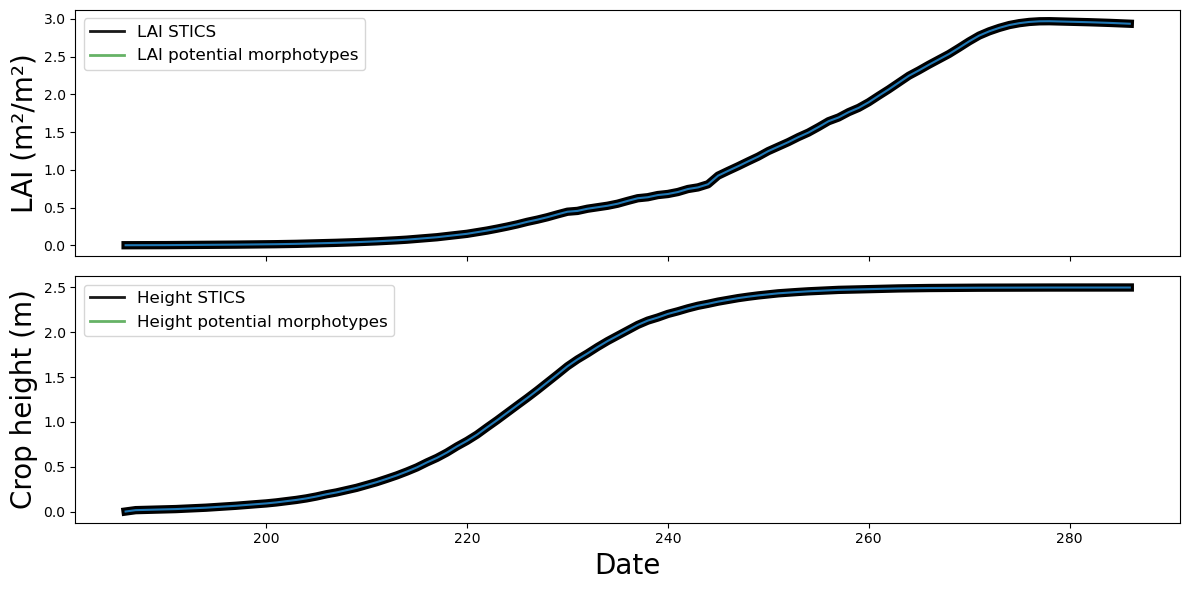

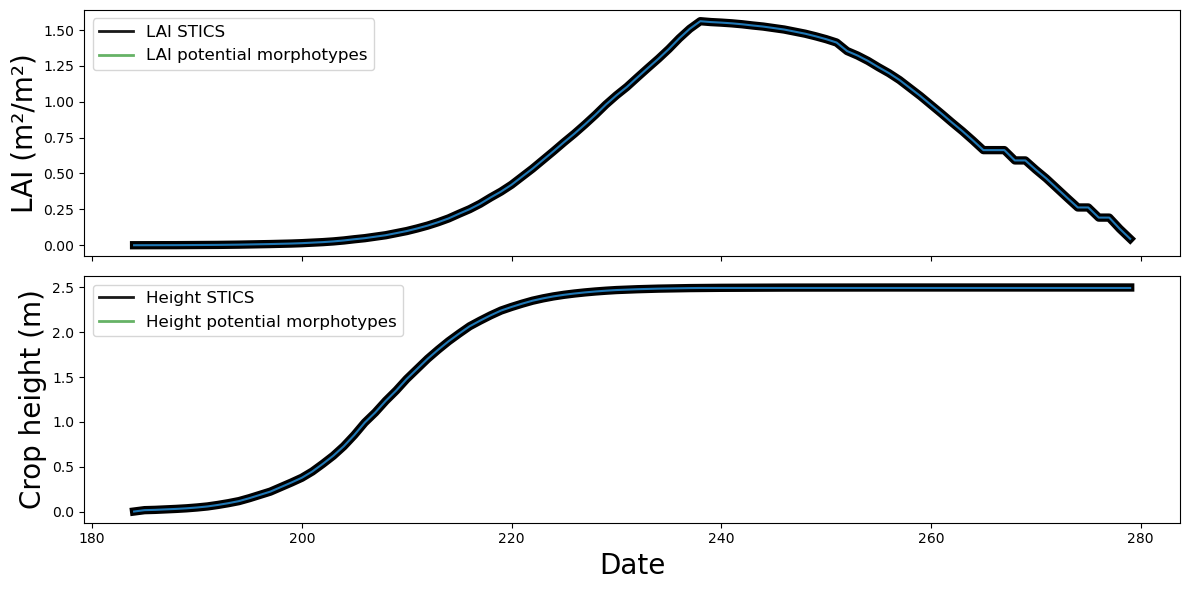

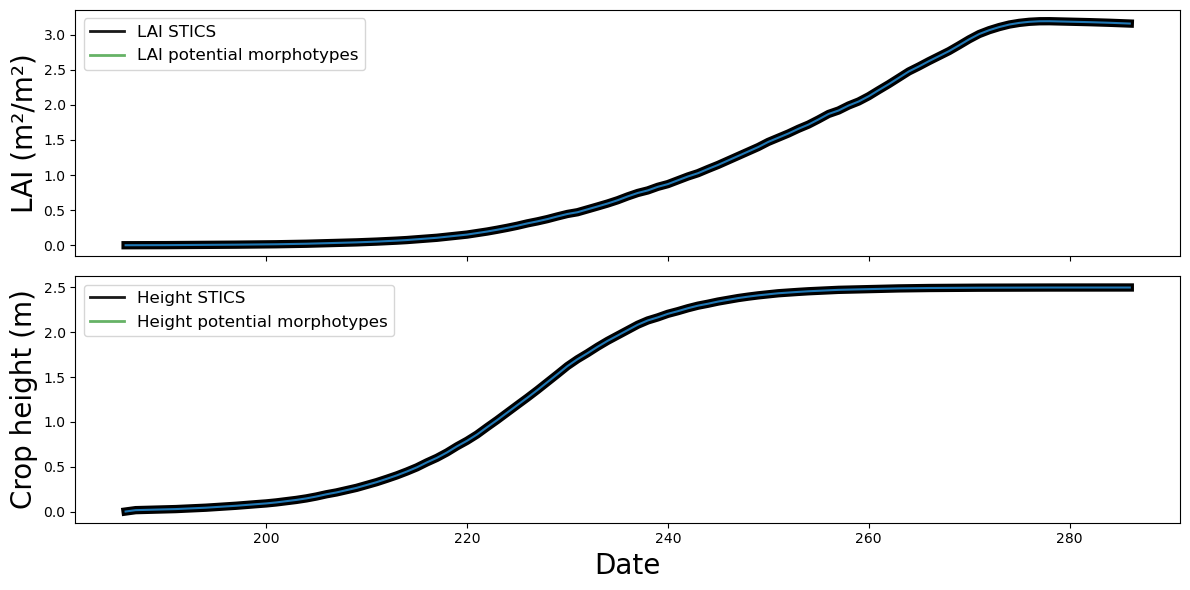

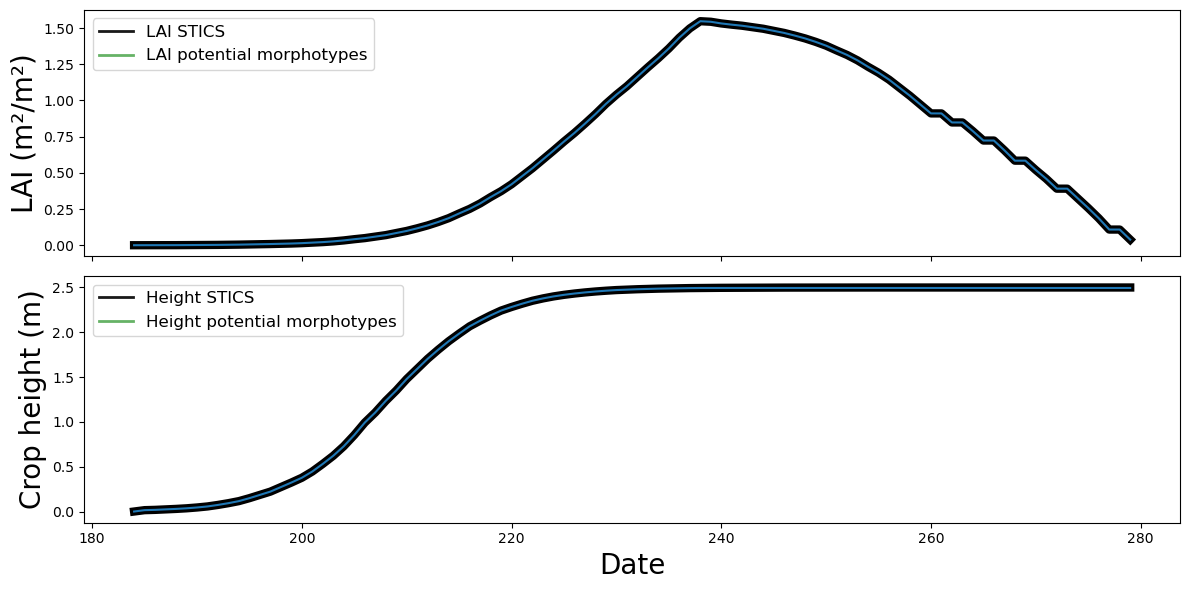

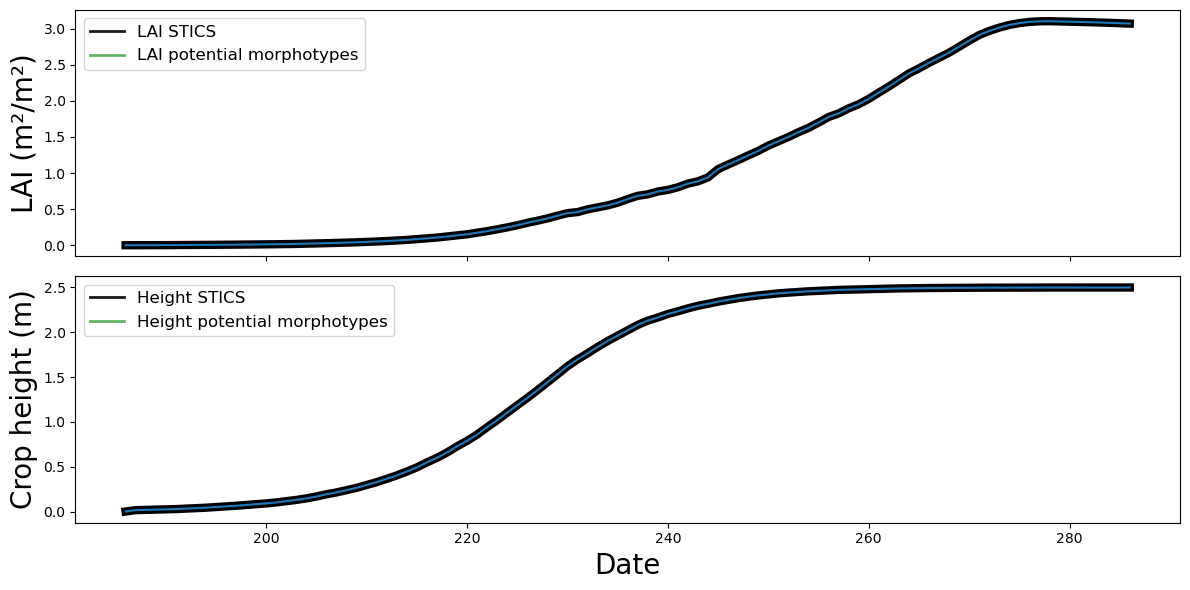

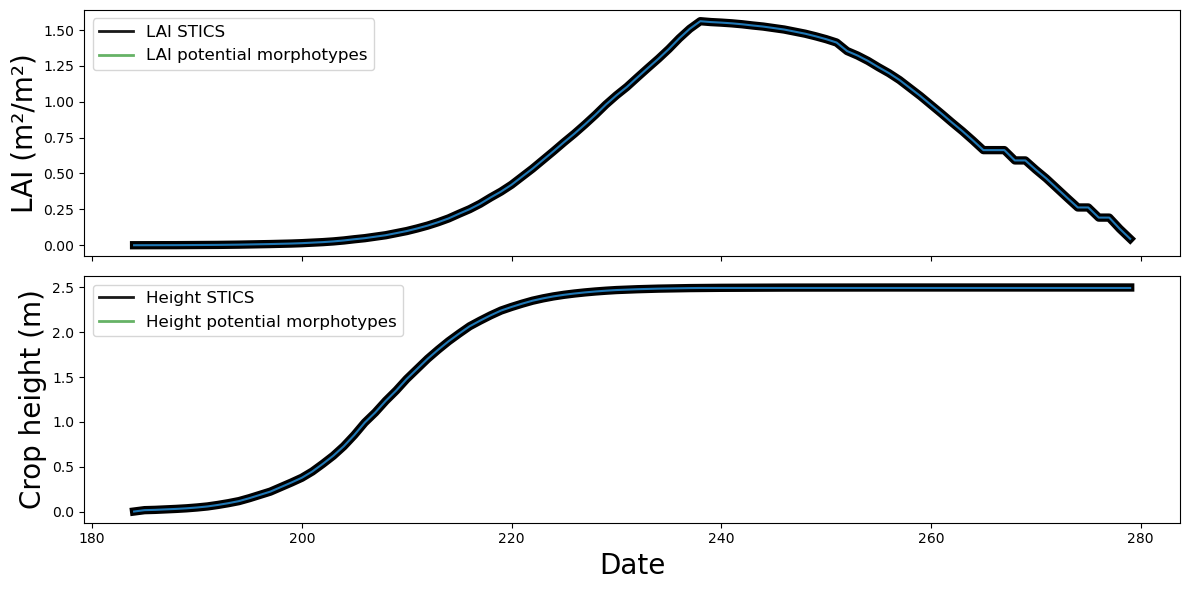

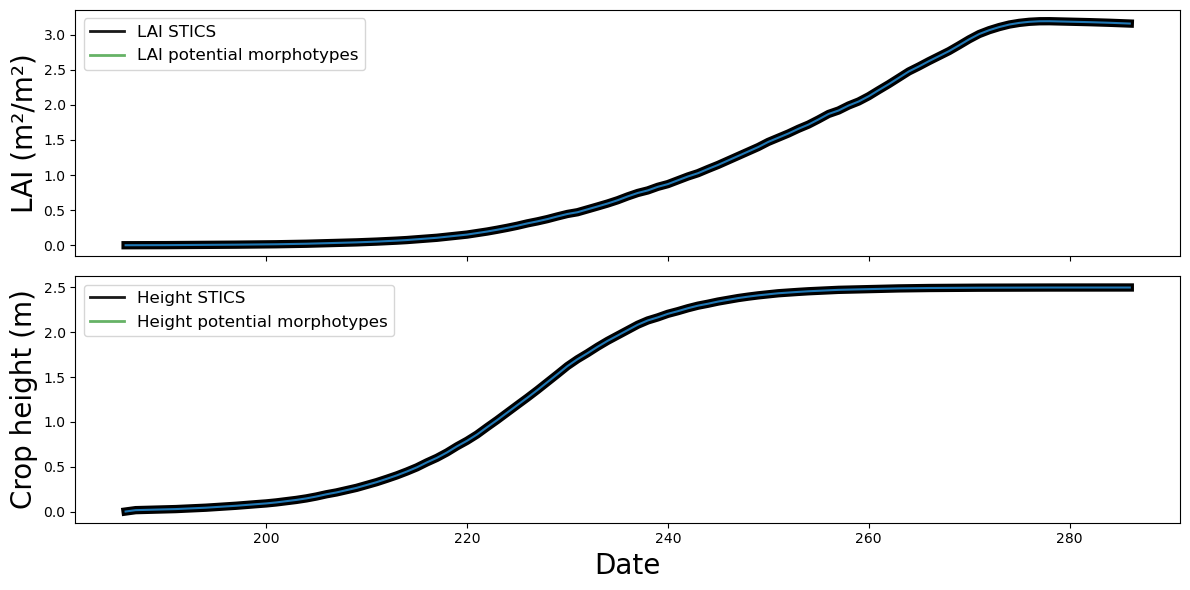

In [11]:
def plot_constained_vs_realized_IC(dates, la, H, leaf_area_plant, height_canopy, sen_leaf_area_plant, density, stics_color="orange", archicrop_color="green"):
    
    # conversion factor
    cf_cm = 100

    dates = range(len(dates))

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)  # 1 row, 2 columns
    axes[0].plot(dates, [(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant, sen_leaf_area_plant)], color=stics_color, linewidth=6)
    axes[0].plot(dates, [a*density/cf_cm**2 for a in la]) # , color=archicrop_color, alpha=0.6)
    # axes[0].set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    axes[0].set_ylabel("LAI (m²/m²)", fontsize=20)

    legend_elements_lai = [
        Line2D([0], [0], color=stics_color, alpha=0.9, lw=2, label='LAI STICS'),
        Line2D([0], [0], color=archicrop_color, alpha=0.6, lw=2, label='LAI potential morphotypes')
    ]
    axes[0].legend(handles=legend_elements_lai, loc=2, prop={'size': 12})

    axes[1].plot(dates, [h/cf_cm for h in height_canopy], color=stics_color, linewidth=6)
    axes[1].plot(dates, [h/cf_cm for h in H]) #, color=archicrop_color, alpha=0.6)
    # axes[1].set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    axes[1].set_xlabel("Date", fontsize=20)
    axes[1].set_ylabel("Crop height (m)", fontsize=20)

    legend_elements_height = [
        Line2D([0], [0], color=stics_color, alpha=0.9, lw=2, label='Height STICS'),
        Line2D([0], [0], color=archicrop_color, alpha=0.6, lw=2, label='Height potential morphotypes')
    ]
    axes[1].legend(handles=legend_elements_height, loc=2, prop={'size': 12})

    # Adjust layout
    plt.tight_layout()

    # Save figure
    # plt.savefig(f"../figures/plot_constrained_vs_realized_IC.png", dpi=1000)

    # Show the plot
    plt.show()

for u,usm in enumerate(usms_str):
    for a,algo in enumerate(algos):
        for p,plant in enumerate(plants):
            plot_constained_vs_realized_IC(dates, realized_la[usm][algo][plant], realized_h[usm][algo][plant], leaf_area_plant[usm][algo][plant], height_canopy[usm][algo][plant], sen_leaf_area_plant[usm][algo][plant], density[usm][algo][plant], stics_color="black")

In [34]:
# Energy in Caribu : MJ.day-1
# Irradiance in Caribu : MJ.m[leaf]-2.day-1
# Incident PAR in STICS : MJ.m[soil]-2.day-1
# Absorbed PAR in STICS : MJ.m[soil]-2.day-1

In [12]:
colors = {
    'STICS' : {'Beer': 'darkorange',
                '2.5D': 'orange'},
    '3D' : {'Beer': 'darkgreen',
            '2.5D': 'green'}
}

linestyles = {
    'STICS' : {'Beer': 'dashed',
                '2.5D': 'solid'},
    '3D' : {'Beer': 'dashed',
            '2.5D': 'solid',
           'mixed': 'solid',
           'alternate': 'dotted',
           'strips': 'dashed'}
}

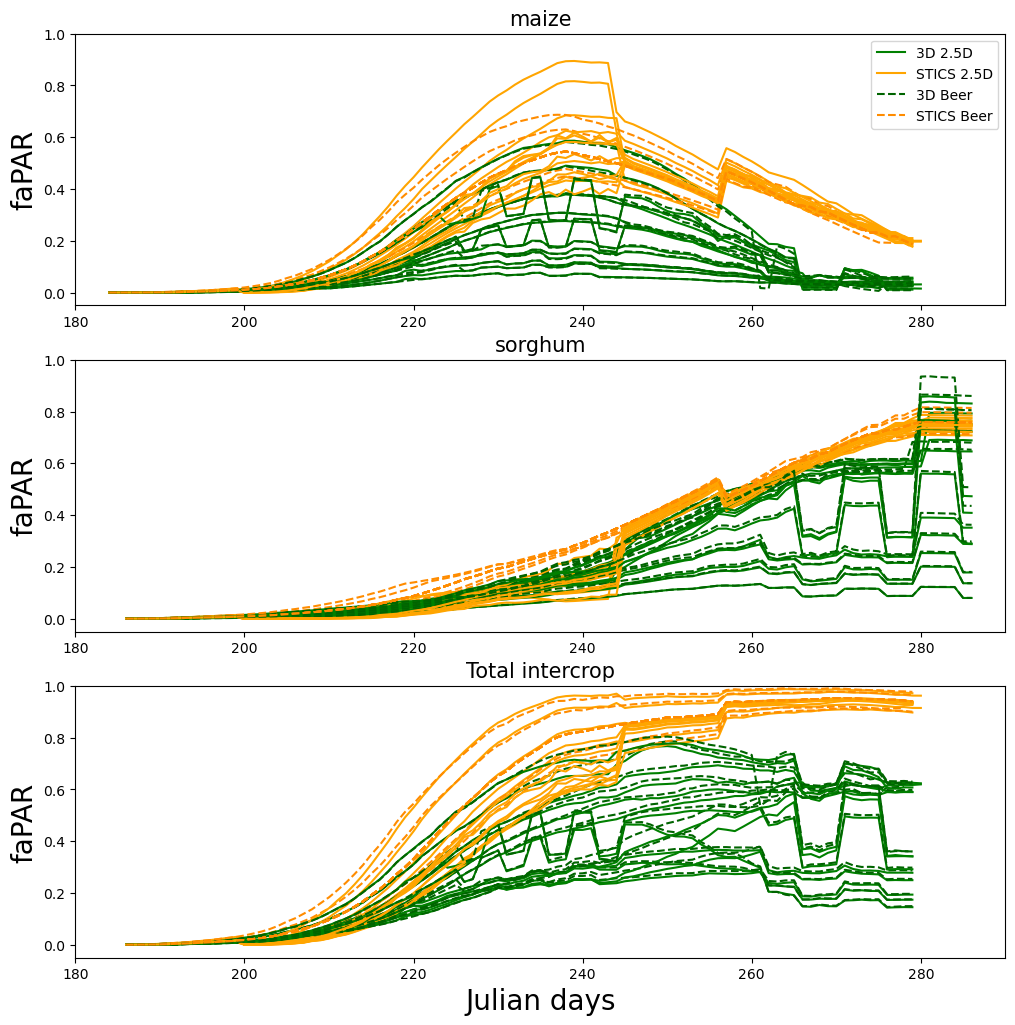

In [13]:
def plot_faPAR_algos_IC(dates, nrj_crop, par_stics, colors, linestyles):

    fig, ax = plt.subplots(3,1,figsize=(12, 12))
    i = 1
    for u,usm in nrj_crop.items():
        for a,algo in usm.items():
            j = 1
            n = 0
            for p,plant in algo.items():
                if i == 1 and j == 1:
                    ax[n].set_title(f"{p}", fontsize=15)
                    ax[n].plot(range(len(plant)), plant, color=colors['3D'][a], linestyle=linestyles['3D'][a], label=f'3D {a}') # label="ArchiCrop x Caribu")
                    ax[n].plot(range(len(plant)), par_stics[u][a][p], color=colors['STICS'][a], linestyle=linestyles['STICS'][a], label=f"STICS {a}")
                else:
                    ax[n].set_title(f"{p}", fontsize=15)
                    ax[n].plot(range(len(plant)), plant, color=colors['3D'][a], linestyle=linestyles['3D'][a]) # label="ArchiCrop x Caribu")
                    ax[n].plot(range(len(plant)), par_stics[u][a][p], color=colors['STICS'][a], linestyle=linestyles['STICS'][a])
                j += 1
                n = 1
            ax[2].plot(range(len(plant)), np.sum([p for p in algo.values()], axis=0), color=colors['3D'][a], linestyle=linestyles['3D'][a]) # label="ArchiCrop x Caribu")
            ax[2].plot(range(len(plant)), np.sum([p for p in par_stics[u][a].values()], axis=0), color=colors['STICS'][a], linestyle=linestyles['STICS'][a])
        i += 1

    ax[2].set_title("Total intercrop", fontsize=15)
    ax[2].set_xlabel("Julian days", fontsize=20) 
    ax[0].legend()

    for a in range(len(ax)):
        ax[a].set_ylabel("faPAR", fontsize=20)
        ax[a].set_xlim(180,290)
        ax[a].set_ylim(-0.05,1)

    plt.savefig(f"../figures/plot_faPAR_algos_IC.png", dpi=1000)

    plt.show()

plot_faPAR_algos_IC(dates, nrj_crop, par_stics, colors, linestyles)

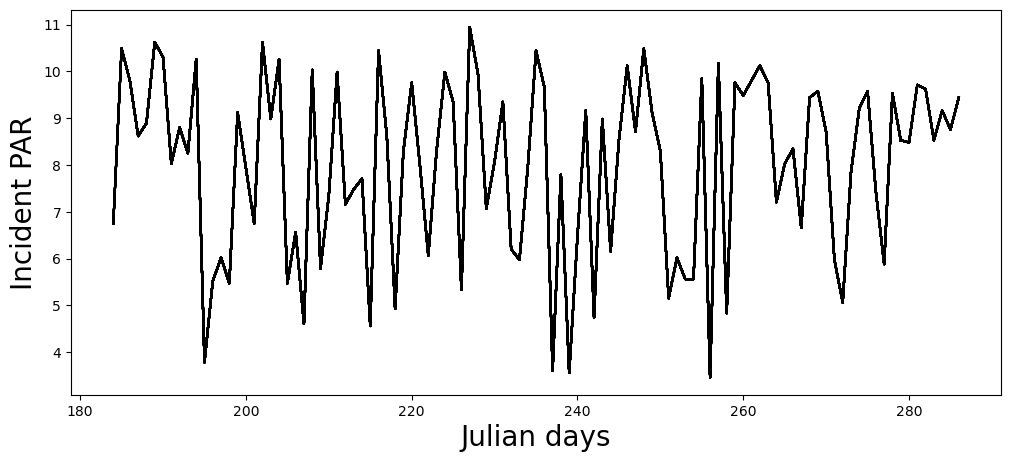

In [211]:
def plot_PARinc(dates, par_inc):

    fig, ax = plt.subplots(figsize=(12, 5))
    for u,usm in par_inc.items():
        for a,algo in usm.items():
            for p,plant in algo.items():
                ax.plot(range(len(plant)), plant, color="black")

    ax.set_xlabel("Julian days", fontsize=20) 
    ax.set_ylabel("Incident PAR", fontsize=20)

    plt.show()

plot_PARinc(dates, par_incident)

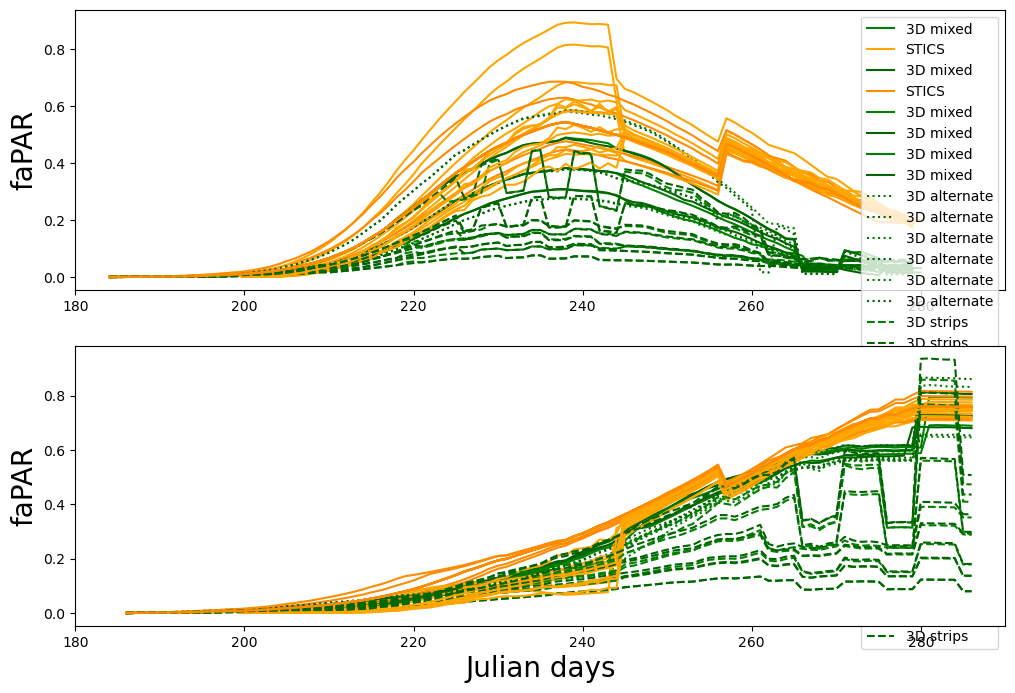

In [213]:
def plot_faPAR_design_IC(dates, nrj_crop, par_stics, colors, linestyles):

    fig, ax = plt.subplots(2,1,figsize=(12, 8))
    i = 1
    for u,usm in nrj_crop.items():
        for a,algo in usm.items():
            j = 1
            n = 0
            if doe_adapt[u][a]["nb_rows_1"] == 0:
                design = "mixed"
            elif doe_adapt[u][a]["nb_rows_1"] == 1:
                design = "alternate"
            else: 
                design = "strips"
            for p,plant in algo.items():
                if i == 1 and j == 1:
                    ax[n].plot(range(len(plant)), plant, color=colors['3D'][a], linestyle=linestyles['3D'][design], label=f'3D {design}') # label="ArchiCrop x Caribu")
                    ax[n].plot(range(len(plant)), par_stics[u][a][p], color=colors['STICS'][a], linestyle='solid', label=f"STICS")
                else:
                    ax[n].plot(range(len(plant)), plant, color=colors['3D'][a], linestyle=linestyles['3D'][design], label=f'3D {design}') # label="ArchiCrop x Caribu")
                    ax[n].plot(range(len(plant)), par_stics[u][a][p], color=colors['STICS'][a], linestyle='solid')
                j += 1
                n = 1
        i += 1

    ax[1].set_xlabel("Julian days", fontsize=20) 
    ax[0].set_ylabel("faPAR", fontsize=20)
    ax[1].set_ylabel("faPAR", fontsize=20)
    ax[0].legend()

    ax[0].set_xlim(180,290)
    ax[1].set_xlim(180,290)

    plt.savefig(f"../figures/plot_faPAR_design_IC.png", dpi=1000)

    plt.show()

plot_faPAR_design_IC(dates, nrj_crop, par_stics, colors, linestyles)

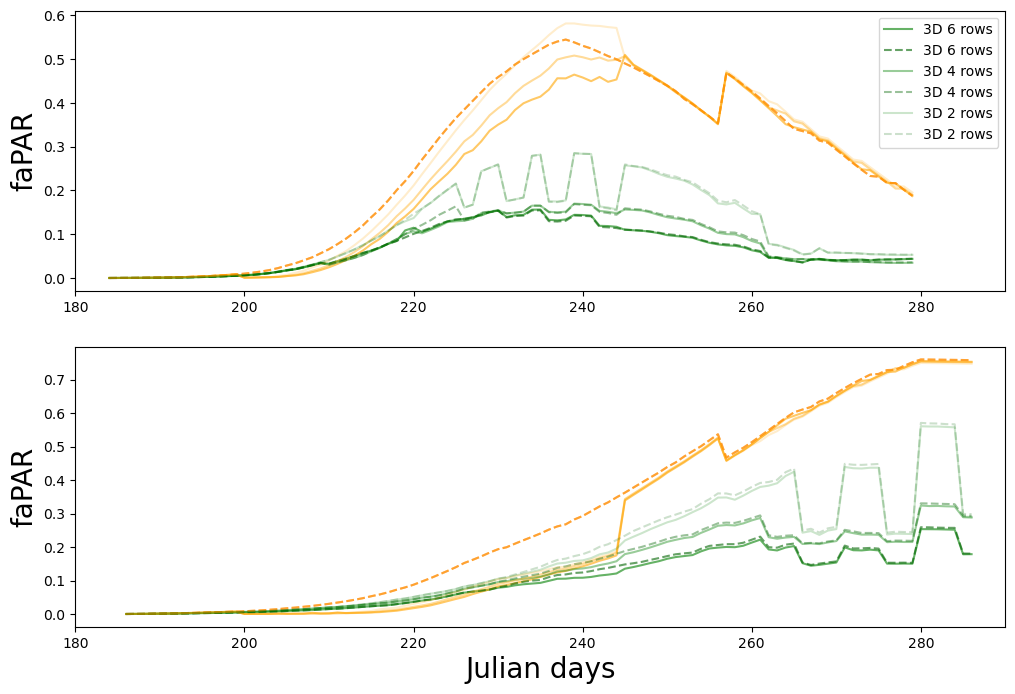

In [224]:
def plot_faPAR_nrows_IC(dates, nrj_crop, par_stics, colors, linestyles):

    fig, ax = plt.subplots(2,1,figsize=(12, 8))
    i = 1
    for u,usm in nrj_crop.items():
        for a,algo in usm.items():
            j = 1
            np = 0
            nrows1 = doe_adapt[u][a]["nb_rows_1"]
            nrows2 = doe_adapt[u][a]["nb_rows_2"]
            if nrows1 > 1 and nrows1 == nrows2:
                for p,plant in algo.items():
                    if i == 1 and j == 1:
                        ax[np].plot(range(len(plant)), plant, color=colors['3D'][a], linestyle=linestyles['3D'][a], alpha=0.1*nrows1, label=f'3D {nrows1} rows') # label="ArchiCrop x Caribu")
                        ax[np].plot(range(len(plant)), par_stics[u][a][p], color=colors['STICS'][a], linestyle=linestyles['STICS'][a], alpha=0.1*nrows1, label=f"STICS")
                    else:
                        ax[np].plot(range(len(plant)), plant, color=colors['3D'][a], linestyle=linestyles['3D'][a], alpha=0.1*nrows1, label=f'3D {nrows1} rows') # label="ArchiCrop x Caribu")
                        ax[np].plot(range(len(plant)), par_stics[u][a][p], color=colors['STICS'][a], linestyle=linestyles['STICS'][a], alpha=0.1*nrows1)
                    j += 1
                    np = 1
        i += 1

    ax[1].set_xlabel("Julian days", fontsize=20) 
    ax[0].set_ylabel("faPAR", fontsize=20)
    ax[1].set_ylabel("faPAR", fontsize=20)
    ax[0].legend()

    ax[0].set_xlim(180,290)
    ax[1].set_xlim(180,290)

    # Save figure
    plt.savefig(f"../figures/plot_faPAR_nrows_IC.png", dpi=1000)

    plt.show()

plot_faPAR_nrows_IC(dates, nrj_crop, par_stics, colors, linestyles)

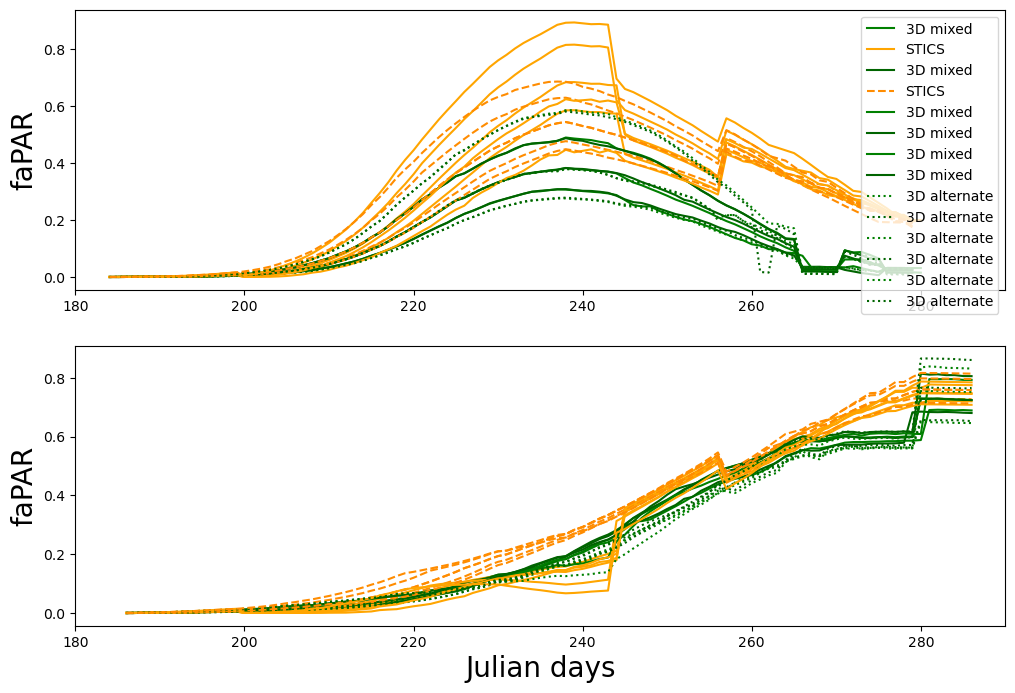

In [221]:
def plot_faPAR_mixed_alt_IC(dates, nrj_crop, par_stics, colors, linestyles):

    fig, ax = plt.subplots(2,1,figsize=(12, 8))
    i = 1
    for u,usm in nrj_crop.items():
        for a,algo in usm.items():
            j = 1
            np = 0
            nrows1 = doe_adapt[u][a]["nb_rows_1"]
            nrows2 = doe_adapt[u][a]["nb_rows_2"]
            if doe_adapt[u][a]["nb_rows_1"] == 0:
                design = "mixed"
            elif doe_adapt[u][a]["nb_rows_1"] == 1:
                design = "alternate"
            else: 
                design = "strips"
            if nrows1 == 0 or nrows1 == 1:
                for p,plant in algo.items():
                    if i == 1 and j == 1:
                        ax[np].plot(range(len(plant)), plant, color=colors['3D'][a], linestyle=linestyles['3D'][design], label=f'3D {design}') # label="ArchiCrop x Caribu")
                        ax[np].plot(range(len(plant)), par_stics[u][a][p], color=colors['STICS'][a], linestyle=linestyles['STICS'][a], label=f"STICS")
                    else:
                        ax[np].plot(range(len(plant)), plant, color=colors['3D'][a], linestyle=linestyles['3D'][design], label=f'3D {design}') # label="ArchiCrop x Caribu")
                        ax[np].plot(range(len(plant)), par_stics[u][a][p], color=colors['STICS'][a], linestyle=linestyles['STICS'][a])
                    j += 1
                    np = 1
        i += 1

    ax[1].set_xlabel("Julian days", fontsize=20) 
    ax[0].set_ylabel("faPAR", fontsize=20)
    ax[1].set_ylabel("faPAR", fontsize=20)
    ax[0].legend()

    ax[0].set_xlim(180,290)
    ax[1].set_xlim(180,290)

    # Save figure
    plt.savefig(f"../figures/plot_faPAR_mixed_alt_IC.png", dpi=1000)

    plt.show()

plot_faPAR_mixed_alt_IC(dates, nrj_crop, par_stics, colors, linestyles)

In [38]:
"""
# vertical light interception
cs, ei, df = illuminate(scene, scene_unit='cm')
cs.plot(ei)


# diffuse light interception
sources = skys.sky_sources()
cs, ei, df = illuminate(scene, light=sources, scene_unit='cm')
cs.plot(ei)

# get score per plant
def score(res):
    return pd.Series({'ei':(res.Ei*res.area).sum() / res.area.sum(),
                              'area': res.area.sum()})
df['nump']=nump
df.groupby('nump').apply(score)
"""

"\n# vertical light interception\ncs, ei, df = illuminate(scene, scene_unit='cm')\ncs.plot(ei)\n\n\n# diffuse light interception\nsources = skys.sky_sources()\ncs, ei, df = illuminate(scene, light=sources, scene_unit='cm')\ncs.plot(ei)\n\n# get score per plant\ndef score(res):\n    return pd.Series({'ei':(res.Ei*res.area).sum() / res.area.sum(),\n                              'area': res.area.sum()})\ndf['nump']=nump\ndf.groupby('nump').apply(score)\n"